<h1 align="center"> EDA </h1>

## **1. IMPORTING LIBRARIES**

In [ ]:
# Importing libraires

import kagglehub
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import math
import numpy as np

## **2. DATA LOADING**

Import the dataset "transactions" and store it as a Pandas DataFrame.

In [ ]:
# 1. Download the latest version from Kaggle
path = kagglehub.dataset_download("umuttuygurr/e-commerce-fraud-detection-dataset")

# 2. Define the full path to the specific CSV file
csv_path = os.path.join(path, "transactions.csv")

# 3. Load the dataset into a pandas DataFrame
df = pd.read_csv(csv_path)

# 4. Verify the data loading
print(f"Dataset successfully loaded from: {csv_path}")

100%|██████████| 5.96M/5.96M [00:00<00:00, 79.8MB/s]

Extracting files...


Dataset successfully loaded from: /root/.cache/kagglehub/datasets/umuttuygurr/e-commerce-fraud-detection-dataset/versions/1/transactions.csv


Check the dataset





In [ ]:
# Check the dataset
df.head()

,transaction_id,user_id,account_age_days,total_transactions_user,avg_amount_user,amount,country,bin_country,channel,merchant_category,promo_used,avs_match,cvv_result,three_ds_flag,transaction_time,shipping_distance_km,is_fraud
0,1,1,141,47,147.93,84.75,FR,FR,web,travel,0,1,1,1,2024-01-06T04:09:39Z,370.95,0
1,2,1,141,47,147.93,107.90,FR,FR,web,travel,0,0,0,0,2024-01-09T20:13:47Z,149.62,0
2,3,1,141,47,147.93,92.36,FR,FR,app,travel,1,1,1,1,2024-01-12T06:20:11Z,164.08,0
3,4,1,141,47,147.93,112.47,FR,FR,web,fashion,0,1,1,1,2024-01-15T17:00:04Z,397.40,0
4,5,1,141,47,147.93,132.91,FR,US,web,electronics,0,1,1,1,2024-01-17T01:27:31Z,935.28,0


## **3. NUMBER OF ROWS AND COLUMNS**

In [ ]:
# Number of rows and columns
print(f"Number of rows and columns: {df.shape}")

Number of rows and columns: (299695, 17)


The dataset contains 299695 observations and 17 variables.

## **4. VARIABLE DESCRIPTIONS**

According to its author, his synthetic dataset recreates realistic fraud behavior across countries, channels, and user profiles.

The dataset aims to replicate the structure and statistical properties of real-world fraud data while remaining fully privacy-safe and open for educational use.

* **transaction_id**: Unique transaction identifier.
* **user_id**: User identifier (each user 40–60 transactions).
* **account_age_days**: Age of user account in days.
* **total_transactions_user**: Number of transactions per user.
* **avg_amount_user**: User’s mean transaction amount.
* **amount**: Transaction amount (USD).
* **country**: User’s country.
* **bin_country**: Country of the card-issuing bank.
* **channel**: “web” or “app”.
* **merchant_category**: Type of purchase: electronics, fashion, grocery, gaming, travel.
* **promo_used**: 0/1 — whether a discount/promo was used.
* **avs_match**: 0/1 — Address Verification result.
* **cvv_result**: 0/1 — CVV code match result.
* **three_ds_flag**: 0/1 — 3D Secure enabled.
* **transaction_time**: Transaction timestamp (UTC).
* **shipping_distance_km**: Distance between billing and shipping addresses.
* **is_fraud**: Target label (1 = fraud, 0 = normal).

## **5. CONCISE SUMMARY**

In [ ]:
# Concise summary
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299695 entries, 0 to 299694
Data columns (total 17 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   transaction_id           299695 non-null  int64  
 1   user_id                  299695 non-null  int64  
 2   account_age_days         299695 non-null  int64  
 3   total_transactions_user  299695 non-null  int64  
 4   avg_amount_user          299695 non-null  float64
 5   amount                   299695 non-null  float64
 6   country                  299695 non-null  object 
 7   bin_country              299695 non-null  object 
 8   channel                  299695 non-null  object 
 9   merchant_category        299695 non-null  object 
 10  promo_used               299695 non-null  int64  
 11  avs_match                299695 non-null  int64  
 12  cvv_result               299695 non-null  int64  
 13  three_ds_flag            299695 non-null  int64  
 14  tran

A preliminary technical review reveals the following key points:

* **Data Integrity:** There are no missing values across any of the columns, which simplifies the initial cleaning phase.
* **Feature Composition:**
    * **Numerical Features (12):** Include transaction details (`amount`, `shipping_distance_km`), user history (`account_age_days`, `total_transactions_user`), and several binary flags (`promo_used`, `cvv_result`, etc.).
    * **Categorical Features (5):** These include geographical data (`country`, `bin_country`), the transaction `channel`, and the `merchant_category`.
* **Target Variable:** The column `is_fraud` is our primary target for classification, represented as a binary integer (0 for legitimate, 1 for fraudulent).
* **Temporal Data:** The `transaction_time` is currently stored as an `object` (string). A critical next step involves converting this to a `datetime` format to extract time-based patterns.

This structure provides a robust foundation for identifying behavioral patterns and anomalies associated with fraudulent activities.

## **6. IDENTIFICATION OF DUPLICATE RECORDS**

In [ ]:
# Identification of duplicate records
df.duplicated().sum()

np.int64(0)

There are no duplicate observations in the dataset.

## **7. IDENTIFYING UNIQUE VALUES**

In [ ]:
# Identifying unique values
for column in df.columns:
  print(f"{column}: {df[column].unique()} UNIQUE: {df[column].nunique()}")

transaction_id: [     1      2      3 ... 299693 299694 299695] UNIQUE: 299695
user_id: [   1    2    3 ... 5998 5999 6000] UNIQUE: 6000
account_age_days: [ 141 1598  954 ...  108 1280  563] UNIQUE: 1801
total_transactions_user: [47 57 40 59 53 50 43 51 54 41 42 52 45 60 58 55 44 56 49 46 48] UNIQUE: 21
avg_amount_user: [147.93  78.39 172.03 ...  26.64 143.73  27.93] UNIQUE: 5347
amount: [  84.75  107.9    92.36 ...  898.46  619.22 1659.7 ] UNIQUE: 60043
country: ['FR' 'US' 'TR' 'PL' 'ES' 'IT' 'RO' 'GB' 'NL' 'DE'] UNIQUE: 10
bin_country: ['FR' 'US' 'RO' 'ES' 'TR' 'DE' 'GB' 'IT' 'PL' 'NL'] UNIQUE: 10
channel: ['web' 'app'] UNIQUE: 2
merchant_category: ['travel' 'fashion' 'electronics' 'grocery' 'gaming'] UNIQUE: 5
promo_used: [0 1] UNIQUE: 2
avs_match: [1 0] UNIQUE: 2
cvv_result: [1 0] UNIQUE: 2
three_ds_flag: [1 0] UNIQUE: 2
transaction_time: ['2024-01-06T04:09:39Z' '2024-01-09T20:13:47Z' '2024-01-12T06:20:11Z' ...
 '2024-10-26T07:40:38Z' '2024-10-27T09:31:56Z' '2024-10-30T11:10:23Z'] 

A detailed inspection of unique values across the 17 features reveals the following insights:

* **Identifiers:** * `transaction_id` is unique for every row (299,695), confirming it as the primary key.
    * There are **6,000 unique users**, indicating an average of ~50 transactions per user. This allows for behavioral profiling.
* **Categorical Diversity:**
    * `country` and `bin_country` both contain 10 unique values. Comparing these two features might reveal geographical mismatches often linked to fraud.
    * `channel` (2), `merchant_category` (5), and several binary flags (0/1) like `promo_used`, `avs_match`, and `cvv_result` are well-defined and ready for encoding.
* **Numerical Distribution:**
    * `total_transactions_user` ranges from 40 to 60, suggesting a balanced history for each user in the dataset.
    * `amount` and `shipping_distance_km` show high cardinality, typical of continuous financial and spatial data.
* **Temporal Specificity:** * There are 297,975 unique timestamps. The small difference compared to the total row count suggests that very few transactions occur at the exact same second, which is expected in high-volume e-commerce.
* **Target Balance:**
    * `is_fraud` contains two classes (0 and 1). The next step will be to quantify the imbalance ratio between these classes.

This distribution confirms the dataset is clean and structured, with a rich mix of categorical and continuous variables for feature engineering.

## **8. SUMMARY OF DESCRIPTIVE STATISTICS**

To gain meaningful insights, we split the operation into three logical groups:

**1. Continuous Numerical Features:** To understand the distribution, scale, and potential outliers in financial and spatial data.

**2. Binary/Flag Features:** To see the frequency of specific conditions (like 3D Secure or CVV match).

**3. Categorical/ID Features:** To check for frequency and distribution of non-numeric data.

In [ ]:
# Summary of descriptive statistics

# 1. Analysis of Continuous Numerical Variables
# These are essential for identifying outliers and scaling needs.
continuous_cols = ['account_age_days', 'total_transactions_user',
                   'avg_amount_user', 'amount', 'shipping_distance_km']
print("--- Continuous Variables Stats ---")
display(df[continuous_cols].describe())

# 2. Analysis of Binary Flags (0/1)
# The mean here represents the percentage of '1s'.
binary_cols = ['promo_used', 'avs_match', 'cvv_result', 'three_ds_flag', 'is_fraud']
print("\n--- Binary Flags Stats (Frequency) ---")
display(df[binary_cols].describe().loc[['count', 'mean']])

# 3. Analysis of Categorical Variables
# This shows the most frequent category (top) and its frequency.
categorical_cols = ['country', 'bin_country', 'channel', 'merchant_category']
print("\n--- Categorical Variables Summary ---")
display(df[categorical_cols].describe(include='object'))

--- Continuous Variables Stats ---


,account_age_days,total_transactions_user,avg_amount_user,amount,shipping_distance_km
count,299695.000000,299695.000000,299695.000000,299695.000000,299695.000000
mean,973.397871,50.673321,148.142973,177.165279,357.049028
std,525.241409,5.976391,200.364624,306.926507,427.672074
min,1.000000,40.000000,3.520000,1.000000,0.000000
25%,516.000000,46.000000,46.190000,42.100000,136.600000
50%,975.000000,51.000000,90.130000,89.990000,273.020000
75%,1425.000000,56.000000,173.450000,191.110000,409.180000
max,1890.000000,60.000000,4565.290000,16994.740000,3748.560000



--- Binary Flags Stats (Frequency) ---


,promo_used,avs_match,cvv_result,three_ds_flag,is_fraud
count,299695.00000,299695.000000,299695.00000,299695.000000,299695.000000
mean,0.15364,0.837999,0.87211,0.784588,0.022062



--- Categorical Variables Summary ---


,country,bin_country,channel,merchant_category
count,299695,299695,299695,299695
unique,10,10,2,5
top,US,US,web,electronics
freq,32430,32295,152226,60220


The initial statistical pass provides critical information for our modeling strategy:

**1. Target Imbalance (The Fraud Ratio)**
* **Fraud Rate:** The mean of `is_fraud` is **0.022**, meaning only **2.2%** of the transactions are fraudulent.
* **Impact:** We are dealing with a **highly imbalanced dataset**. Accuracy will be a misleading metric; we must prioritize **Precision-Recall AUC** and **F1-Score**.

**2. Anomalies and Outliers in Transactions**
* **Transaction Amount:** While 75% of transactions are under **\$191.11**, the maximum value reaches **\$16,994.74**. This massive gap between the 75th percentile and the max suggests significant outliers that are often characteristic of fraudulent behavior.
* **Shipping Distance:** Similar to amount, the max distance (**3,748 km**) is nearly 10 times the 75th percentile (**409 km**).

**3. Security and Promotion Flags**
* **Verification Gaps:** About **16%** of transactions failed the Address Verification (`avs_match` mean = 0.83) and **13%** failed the CVV check. These features will likely be top predictors for the model.
* **3D Secure:** **78%** of transactions used 3D Secure, suggesting a relatively high adoption of security protocols in this sample.
* **Promotions:** Only **15%** of transactions used a promo code.

**4. Categorical Dominance**
* **Top Market:** The **United States (US)** is the most frequent country for both the user and the card issuer.
* **Preferred Channel:** The **Web** channel accounts for the vast majority of transactions (~152k out of 299k).
* **Category:** **Electronics** is the most common merchant category.

**5. User Loyalty**
* **Account Age:** The average account age is **973 days** (~2.6 years), indicating this dataset represents an established user base rather than just new accounts.

## **9. DISTRIBUTION GRID BY FRAUD STATUS**

To conduct an exhaustive exploratory data analysis (EDA), we are plotting the distribution of all relevant features in the dataset. This "stress-test" visualization aims to:

1. **Detect Subtle Correlations:** Uncover hidden patterns in features that might seem secondary but could hold predictive power for fraud.
2. **Identify Data Skewness:** Systematically check every numerical feature for extreme values or irregular distributions.
3. **Verify Categorical Balance:** Ensure that categorical features (countries, channels, categories) have enough representation across all labels.


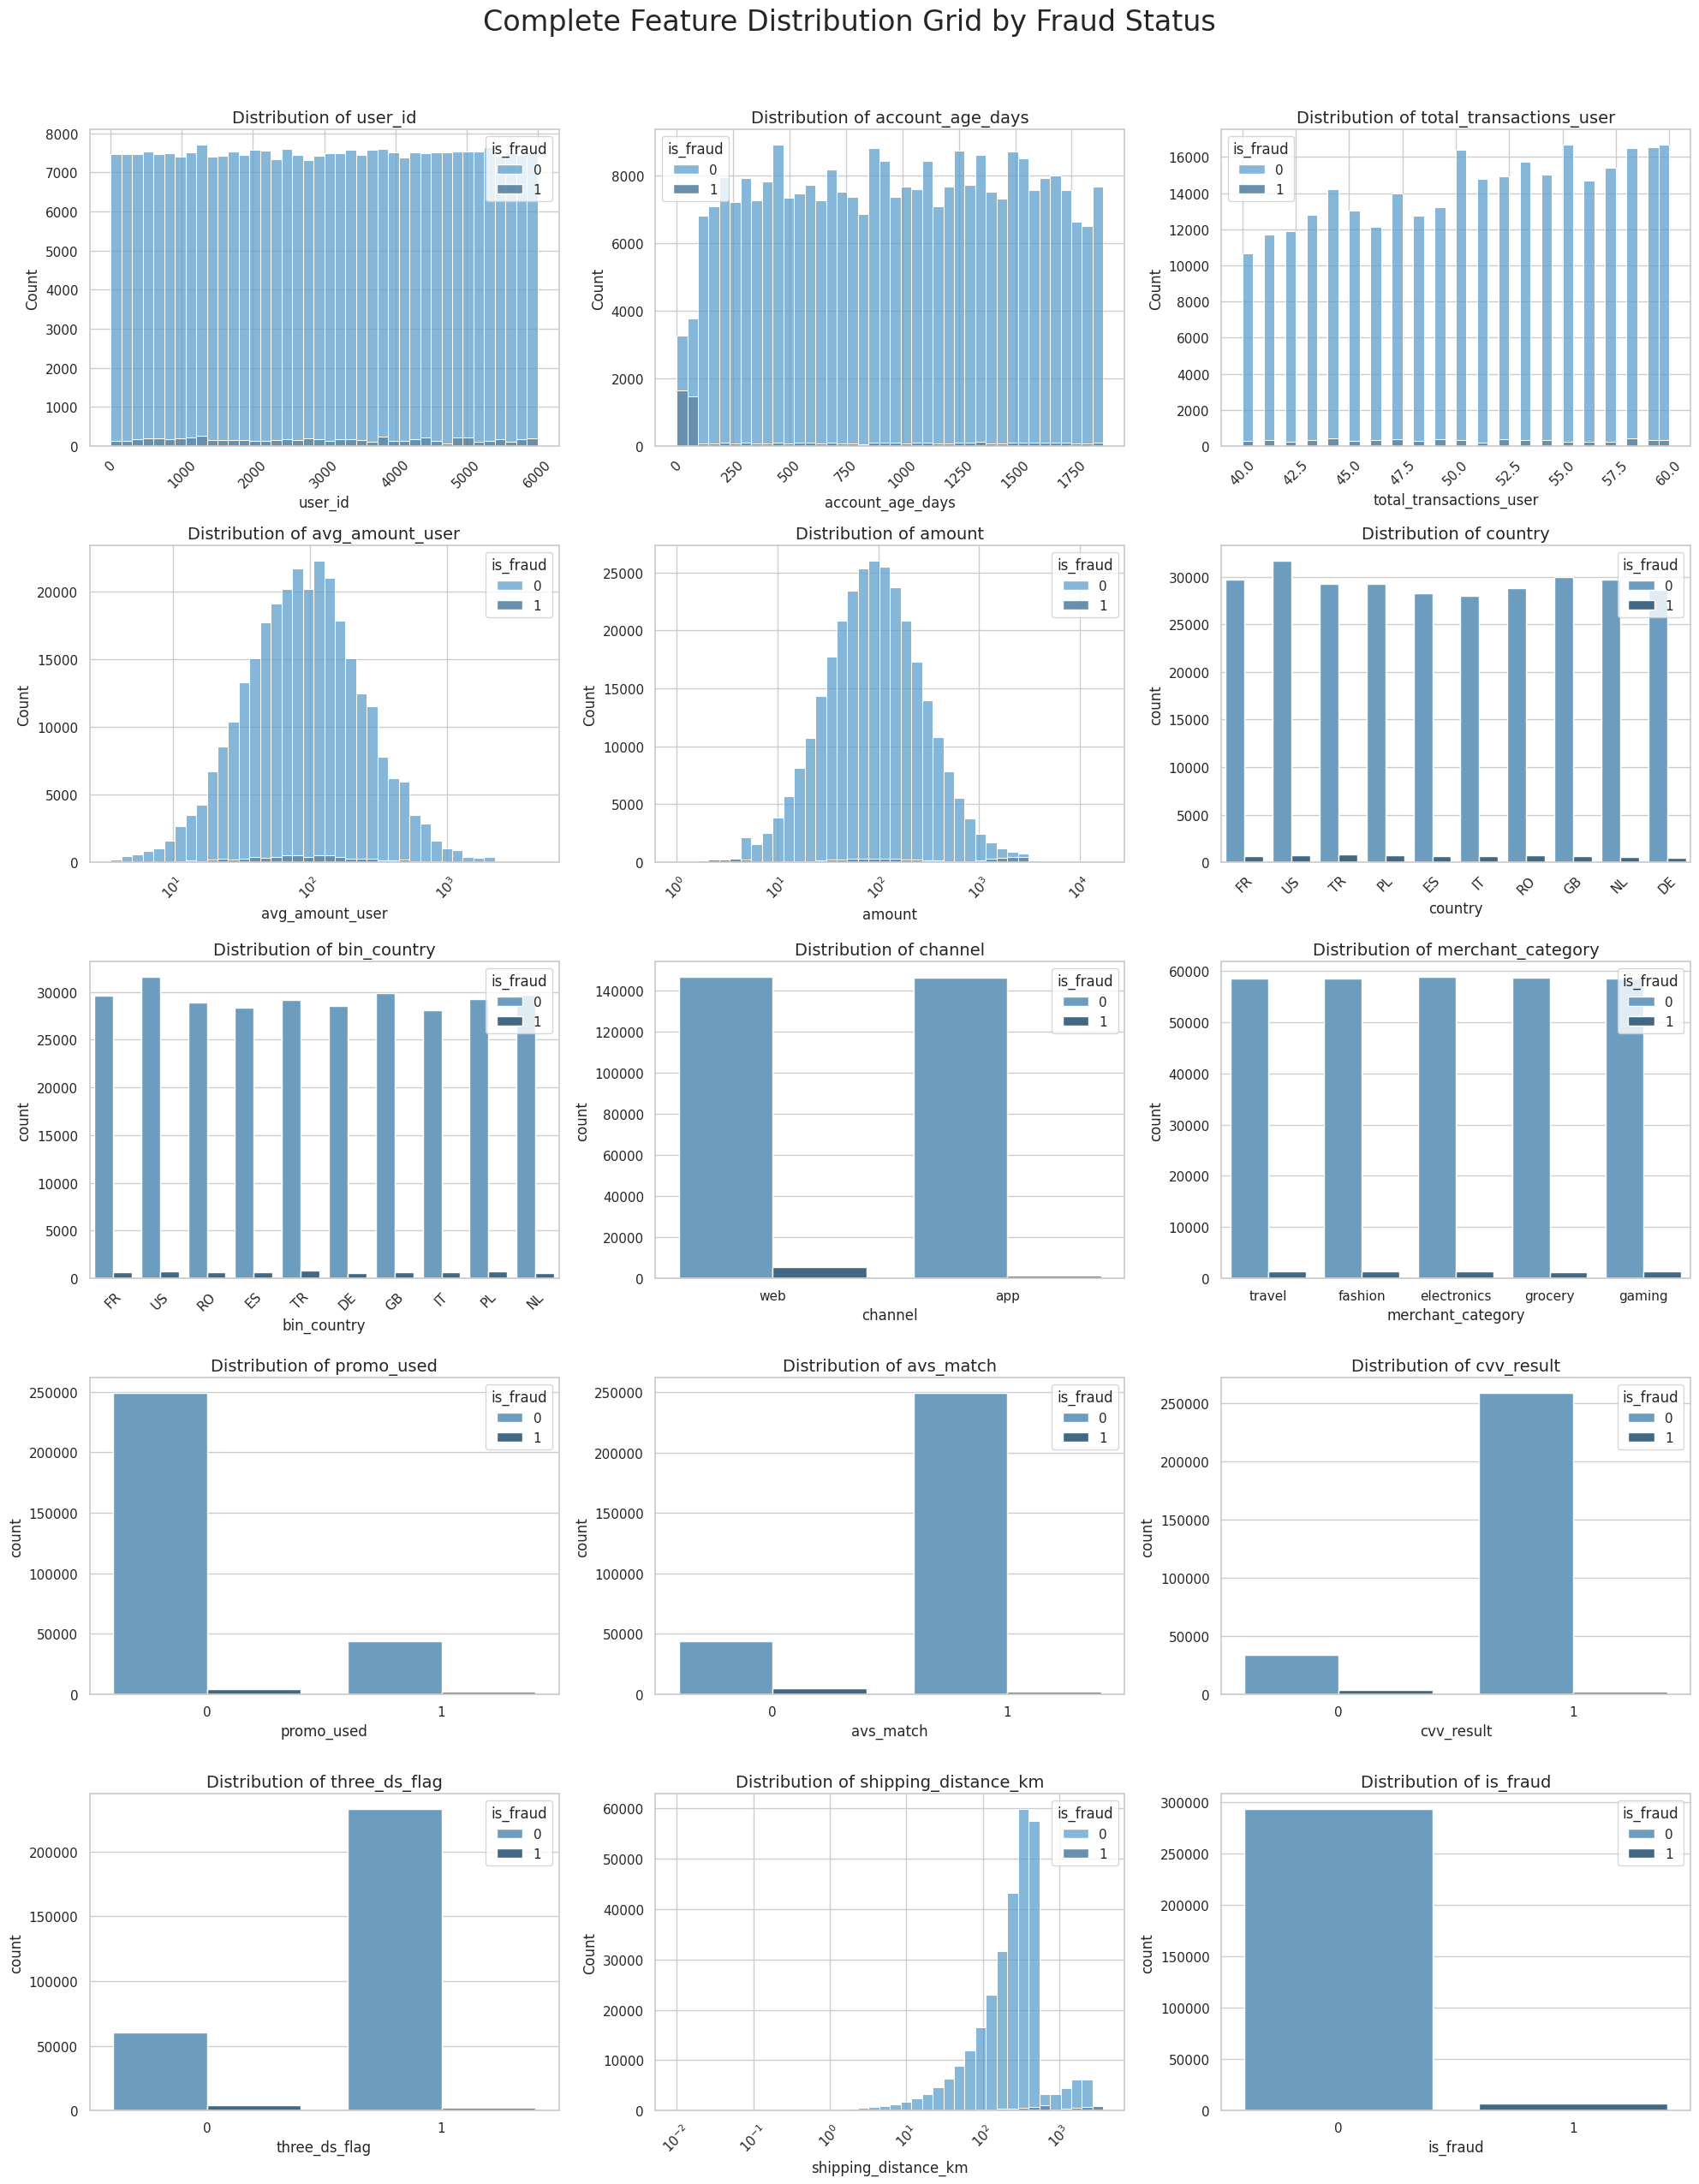

In [ ]:
# Distribution grid by fraud status

# 1. Prepare the list of columns to plot (excluding IDs and timestamps)
# We exclude 'transaction_id' and 'transaction_time' due to extreme cardinality
cols_to_plot = [col for col in df.columns if col not in ['transaction_id', 'transaction_time']]
n_cols = 3
n_rows = math.ceil(len(cols_to_plot) / n_cols)

# 2. Set the visual theme
sns.set_theme(style="whitegrid")
blue_palette = sns.color_palette("Blues_d", n_colors=2)

# 3. Create the figure mosaic
fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(20, n_rows * 5))
fig.suptitle('Complete Feature Distribution Grid by Fraud Status', fontsize=24, y=1.02)

axes = axes.flatten()

for i, col in enumerate(cols_to_plot):
    # Determine the type of plot based on data type and cardinality
    if df[col].dtype in ['int64', 'float64'] and df[col].nunique() > 10:
        # Use histogram for continuous/high-cardinality numerical data
        # We use a log scale for 'amount' and 'avg_amount_user' to handle outliers without filtering
        log_scale = True if col in ['amount', 'avg_amount_user', 'shipping_distance_km'] else False
        sns.histplot(data=df, x=col, hue='is_fraud', multiple="stack",
                     palette=blue_palette, ax=axes[i], bins=40, log_scale=log_scale)
    else:
        # Use countplot for categorical or low-cardinality numerical data (flags)
        sns.countplot(data=df, x=col, hue='is_fraud', palette=blue_palette, ax=axes[i])

    axes[i].set_title(f'Distribution of {col}', fontsize=14)
    axes[i].tick_params(axis='x', rotation=45 if df[col].nunique() > 5 else 0)

# 4. Remove empty subplots if any
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Below is a comprehensive breakdown of the observed patterns:

**1. Target Variable: Strong Class Imbalance**

The distribution of `is_fraud` clearly shows that:

* The vast majority of transactions belong to the **non-fraud (0)** class.
* Fraudulent transactions (1) represent only a very small fraction of the dataset.

This has critical implications for modeling:

* Accuracy will not be an appropriate evaluation metric.
* It will be necessary to use:
  * `F1-score`
  * `Recall`
  * `Precision`
  * `ROC-AUC`
  * `PR-AUC`

It is also advisable to apply:
* balancing techniques (`SMOTE`, undersampling, class weights)
* models robust to imbalance (`XGBoost`, `LightGBM`, balanced Random Forest)

This imbalance also explains why fraudulent cases are barely visible in many histograms.

**2. Numerical Variables**

 `amount`

The transaction amount distribution appears approximately log-normal:

* High concentration around medium transaction amounts.
* Long right tail for large transactions.
* Fraudulent transactions seem slightly more dispersed toward higher amounts.

Interpretation

* High-value transactions may carry a higher relative fraud risk.
* Fraud likely depends not on the amount itself, but on extreme or anomalous values.


`avg_amount_user`

This variable also follows an approximately normal/log-normal distribution.

Observations:

* Most users exhibit relatively stable average spending behavior.
* Fraud may be detectable when:
  * a purchase deviates significantly from the user’s historical behavior.

`account_age_days`

Account age appears relatively uniform.

However, visually there seems to be:
* a slight concentration of fraud among younger accounts.

Interpretation:

This aligns with real-world scenarios involving:
* newly created accounts
* synthetic accounts
* opportunistic fraud

Older accounts are generally more trustworthy.

Suggested Bins

* `<30 days`
* `30–180`
* `180–365`
* `>365`


 `total_transactions_user`

The distribution is relatively homogeneous between 40 and 60 transactions.

 Interpretation

* There does not appear to be a strong visual correlation.
* However, in real-world datasets, users with very few transactions are often riskier.

Possible explanations:
* the dataset may already be pre-filtered
* the variable could be simulated
* the range may have been artificially constrained

`shipping_distance_km`

This is one of the most interesting variables.

Observations:

* Extremely skewed distribution.
* Most transactions are concentrated at short distances.
* Long tail toward very large shipping distances.

Fraud Relevance:

This is often highly relevant in fraud detection:

* shipments far from the customer’s usual location
* fraudulent dropshipping
* reshipping or triangulation schemes

It is highly likely that:
* anomalous shipping distances increase fraud risk.

**3. Categorical Variables**

`country` and `bin_country`

The distributions are fairly balanced across countries.

Observations:

* No country appears overwhelmingly dominant.
* Some countries show slight differences in fraud incidence, although visually subtle.

Important Insight:

The combination of:
* `country`
* `bin_country`
* `shipping_distance_km`

could be extremely predictive.

`channel`

The `channel` variable appears relatively balanced.

Interpretation:

* The channel alone may not be highly discriminative.
* However, combined with other variables, it could add predictive value.

`merchant_category`

Fairly balanced.

Fraud Relevance:

In real-world fraud:
* electronics
* gaming
* travel

often exhibit higher fraud rates because they involve:
* easily resellable goods
* digital products
* immediate fulfillment

**4. Authentication and Verification Variables**

These are likely among the most predictive variables in the dataset.

`avs_match`

Observations

* When `avs_match = 1`, legitimate transactions clearly dominate.
* When `avs_match = 0`, fraud increases proportionally.

Interpretation:

* mismatch between billing address and card data
* classic fraud pattern

This is an extremely important feature.

`cvv_result`

A similar pattern emerges:

* `cvv_result = 1` appears associated with legitimate activity.
* `cvv_result = 0` concentrates relatively more fraud.

Interpretation:

Many attackers do not possess the real CVV.

This is likely a highly predictive variable.

`three_ds_flag`

Observations:

* Transactions protected by 3DS (`1`) appear safer.
* Fraud seems relatively more concentrated in transactions without 3DS.

Interpretation:

Strong authentication reduces fraud risk.

This is another high-value predictive feature.

`promo_used`

This variable may hide interesting patterns.

Possible Interpretations:

* promotional abuse
* mass account creation
* coupon fraud

**5. Potentially Low-Value Variables**

`user_id`

The uniform distribution suggests:

* it is simply an identifier
* it should not be used directly for modeling

Risks:

Using it directly may cause:
* overfitting
* leakage

**6. Potentially Important Relationships**

The univariate plots are useful, but fraud usually emerges from combinations of variables.

Potential High-Risk Combinations:

* high amount + new account
* long shipping distance + different BIN country
* no CVV + no AVS + no 3DS
* electronics/travel + high amount
* promo used + young account

**7. Modeling Implications**

Variables with the Highest Predictive Potential:

Most likely:

1. `cvv_result`
2. `avs_match`
3. `three_ds_flag`
4. `shipping_distance_km`
5. `amount`
6. `account_age_days`
7. country relationships


**8. General Conclusion**

The dataset presents a structure that is highly consistent with a realistic e-commerce fraud detection problem:

The verification variables (`CVV`, `AVS`, `3DS`) appear to contain the strongest signal, while behavioral variables (`amount`, `shipping_distance_km`, `account_age_days`) likely provide contextual detection capability.

At first glance, fraud does not appear separable through a single variable, which suggests that:

* the problem will require non-linear models,
* interaction effects,
* and careful feature engineering.

This is exactly the type of structure where tree-based models (`XGBoost`, `LightGBM`, `CatBoost`) typically perform exceptionally well.

## **10. TEMPORAL ANALYSIS**

###**10.1. TEMPORAL FEATURE ENGINEERING**

The `transaction_time` column, currently stored as a generic string object, contains high-resolution temporal data that is vital for fraud detection. Fraudulent activities often exhibit strong cyclical patterns, as attackers may exploit specific time windows when human monitoring is reduced or during high-volume periods (like sales or weekends) to blend in.

In this section, we perform the following operations:
1. **Type Conversion:** Convert the `transaction_time` from a string to a specialized `datetime` object.
2. **Feature Extraction:** Derive new categorical and numerical features from the timestamp:
    * `hour`: To detect night-time attacks.
    * `day_of_week`: To identify if fraud peaks during weekends.
    * `month`: To observe monthly trends or seasonality.
    * `is_weekend`: A binary flag to simplify weekend vs. weekday analysis.

These new features will transform a single raw timestamp into multiple dimensions that a machine learning model can easily interpret.

In [ ]:
# Temporal feature engineering

# 1. Convert transaction_time to datetime objects
# The 'Z' at the end indicates UTC time
df['transaction_time'] = pd.to_datetime(df['transaction_time'])

# 2. Extract basic temporal features
df['hour'] = df['transaction_time'].dt.hour
df['day_of_week'] = df['transaction_time'].dt.dayofweek  # Monday=0, Sunday=6
df['month'] = df['transaction_time'].dt.month
df['day'] = df['transaction_time'].dt.day

# 3. Create a binary flag for weekends
# 5 is Saturday, 6 is Sunday
df['is_weekend'] = df['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)

# 4. Define a 'part_of_day' feature for easier grouping
def get_part_of_day(hour):
    if 0 <= hour < 6:
        return 'night'
    elif 6 <= hour < 12:
        return 'morning'
    elif 12 <= hour < 18:
        return 'afternoon'
    else:
        return 'evening'

df['part_of_day'] = df['hour'].apply(get_part_of_day)

# 5. Display the newly created features
print("New temporal features created:")
print(df[['transaction_time', 'hour', 'day_of_week', 'month', 'is_weekend', 'part_of_day']].head())

# Check the data types again to confirm conversion
print("\nUpdated Dtypes:")
print(df[['transaction_time', 'hour', 'day_of_week', 'month', 'is_weekend', 'part_of_day']].dtypes)

New temporal features created:
           transaction_time  hour  day_of_week  month  is_weekend part_of_day
0 2024-01-06 04:09:39+00:00     4            5      1           1       night
1 2024-01-09 20:13:47+00:00    20            1      1           0     evening
2 2024-01-12 06:20:11+00:00     6            4      1           0     morning
3 2024-01-15 17:00:04+00:00    17            0      1           0   afternoon
4 2024-01-17 01:27:31+00:00     1            2      1           0       night

Updated Dtypes:
transaction_time    datetime64[ns, UTC]
hour                              int32
day_of_week                       int32
month                             int32
is_weekend                        int64
part_of_day                      object
dtype: object


###**10.2. FRAUD PROBABILITY BY HOUR OF THE DAY**

To determine if there is a temporal signature to fraudulent activity, we analyze the **fraud rate** across a 24-hour cycle.

Unlike a simple count of transactions, calculating the mean of `is_fraud` per hour provides the **probability** of a transaction being fraudulent at any given time. This visualization is crucial for identifying:
* **Off-Peak Vulnerabilities:** High fraud rates during late-night or early-morning hours when monitoring might be less intensive.
* **Peak-Time Noise:** Periods where high transaction volume is used by attackers as a "smokescreen" to hide fraudulent attempts.
* **Cyclical Trends:** Any recurring patterns that could be used for time-based risk scoring in our predictive model.



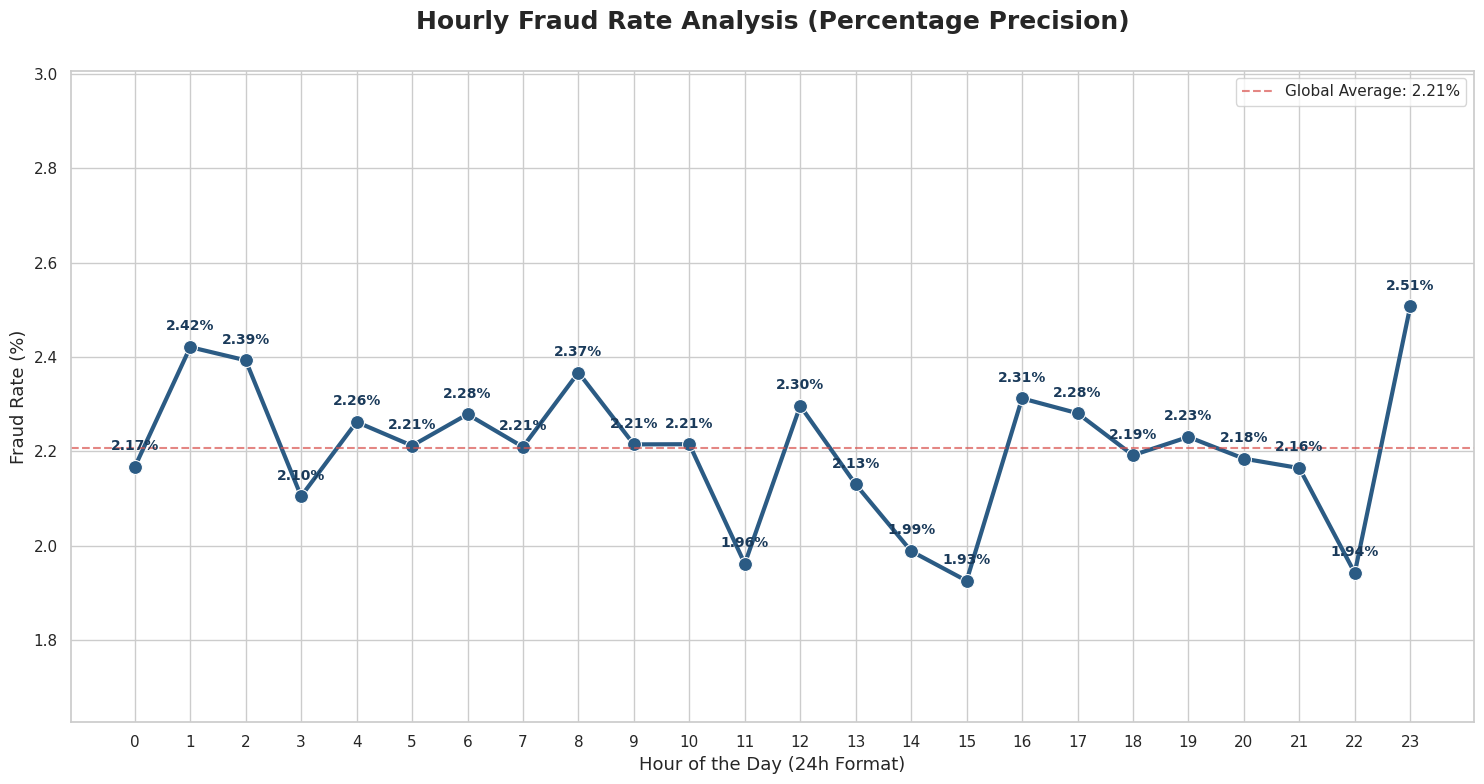

In [ ]:
# Fraud Probability by Hour of the Day

# Set the visual style and figure size
plt.figure(figsize=(15, 8))
sns.set_theme(style="whitegrid")

# 1. Calculate the mean fraud rate per hour and convert to percentage
# We group by 'hour' and apply the mean to 'is_fraud', then multiply by 100
hourly_fraud = df.groupby('hour')['is_fraud'].mean() * 100

# 2. Create the line plot
# We use markers to clearly identify the data points for each hour
ax = sns.lineplot(x=hourly_fraud.index, y=hourly_fraud.values,
                  marker='o', markersize=10, color='#2b5b84', linewidth=3)

# 3. Add data labels to each point
for x, y in zip(hourly_fraud.index, hourly_fraud.values):
    ax.annotate(f'{y:.2f}%',
                xy=(x, y),
                xytext=(0, 12), # 12pts vertical offset
                textcoords='offset points',
                ha='center',
                fontsize=10,
                fontweight='bold',
                color='#1a3a5a')

# 4. Final chart customization
plt.title('Hourly Fraud Rate Analysis (Percentage Precision)', fontsize=18, fontweight='bold', pad=30)
plt.xlabel('Hour of the Day (24h Format)', fontsize=13)
plt.ylabel('Fraud Rate (%)', fontsize=13)

# Ensure the X-axis shows every hour explicitly
plt.xticks(range(0, 24))

# Adjust Y-axis limits to leave space for the annotations
plt.ylim(hourly_fraud.min() - 0.3, hourly_fraud.max() + 0.5)

# 5. Add a reference line for the Global Fraud Average
global_avg_pct = df['is_fraud'].mean() * 100
plt.axhline(global_avg_pct, color='#d9534f', linestyle='--', alpha=0.7,
            label=f'Global Average: {global_avg_pct:.2f}%')

plt.legend(frameon=True, facecolor='white', loc='upper right')
plt.tight_layout()
plt.show()

**1. Stability and Uniform Distribution**
* **Minimal Variance:** The fraud rate is remarkably stable throughout the 24-hour cycle. The values fluctuate within a very narrow range, from a minimum of **1.93%** (at 15:00) to a maximum of **2.51%** (at 23:00).
* **Comparison to Global Average:** The global average fraud rate is **2.24%** (indicated by the red dashed line). Most hourly data points deviate from this mean by less than **0.3 percentage points**.

**2. Key Observations**
* **Peak Hour:** The highest incidence of fraud occurs at **23:00 (11 PM)** with **2.51%**. While this is the highest point, it does not represent a massive surge compared to other hours.
* **Low-Risk Window:** The period between **14:00 and 15:00** shows a slight dip in fraud activity, reaching the daily low of **1.93%**.
* **Late Night Patterns:** Contrary to typical fraud datasets where night hours show significant spikes, this specific dataset shows that fraud is almost as likely at 3 AM (**2.10%**) as it is at 3 PM (**1.93%**).

**3. Strategic Conclusion for Feature Engineering**

The **Hour of the Day** feature exhibits a near-uniform distribution in relation to the target variable (`is_fraud`).

* **Predictive Power:** In its raw categorical form, the `hour` feature is unlikely to be a "smoking gun" for the model.
* **Next Steps:** Instead of relying on absolute time, we should investigate **behavioral velocity** (e.g., the time elapsed between consecutive transactions for the same user) to find stronger indicators of suspicious activity.

### **10.3. SEASONALITY ANALYSIS (WEEKLY & MONTHLY CYCLES)**

To complete our temporal study, we shift our focus from hours to larger calendar cycles. Fraudsters often synchronize their activities with human economic behavior, such as salary payments or leisure time.

In this section, we analyze two key dimensions:
1.  **Day of the Week:** We examine if fraud rates increase during weekends (`is_weekend`), when banking oversight might be perceived as lower.
2.  **Day of the Month:** We look for "Payday Effects," where fraudulent activity might spike during the first or last days of the month to blend in with high volumes of legitimate consumer spending.

By plotting these side-by-side, we can determine if the date serves as a more reliable risk indicator than the hour of the transaction.

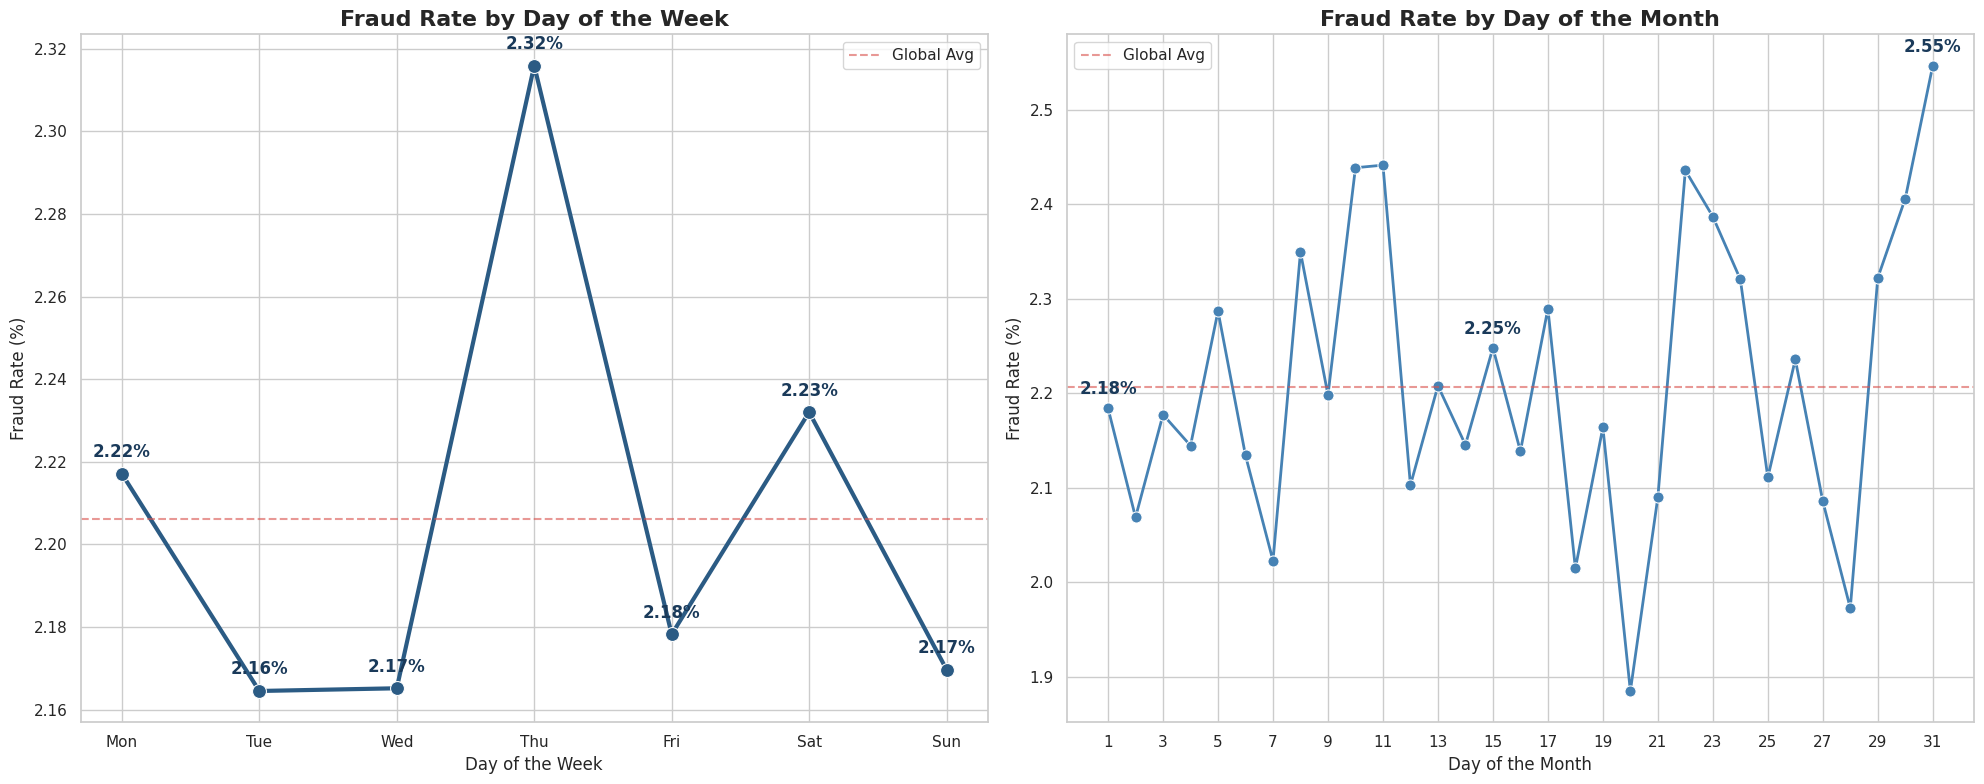

In [ ]:
# Seasonality Analysis (Weekly & Monthly Cycles)

# Create a figure with two subplots (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
sns.set_theme(style="whitegrid")

# --- SUBPLOT 1: FRAUD RATE BY DAY OF THE WEEK ---

# Calculate mean fraud rate per day of the week (0=Monday, 6=Sunday)
day_week_fraud = df.groupby('day_of_week')['is_fraud'].mean() * 100
day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

sns.lineplot(x=day_week_fraud.index, y=day_week_fraud.values,
             marker='o', markersize=10, color='#2b5b84', linewidth=3, ax=axes[0])

# Add labels for each day
for x, y in zip(day_week_fraud.index, day_week_fraud.values):
    axes[0].annotate(f'{y:.2f}%', xy=(x, y), xytext=(0, 12),
                     textcoords='offset points', ha='center', fontweight='bold', color='#1a3a5a')

axes[0].set_title('Fraud Rate by Day of the Week', fontsize=16, fontweight='bold')
axes[0].set_xticks(range(7))
axes[0].set_xticklabels(day_names)
axes[0].set_ylabel('Fraud Rate (%)')
axes[0].set_xlabel('Day of the Week')

# --- SUBPLOT 2: FRAUD RATE BY DAY OF THE MONTH ---

# Calculate mean fraud rate per day of the month (1-31)
day_month_fraud = df.groupby('day')['is_fraud'].mean() * 100

sns.lineplot(x=day_month_fraud.index, y=day_month_fraud.values,
             marker='o', markersize=8, color='#4682B4', linewidth=2, ax=axes[1])

# Add labels for specific points (start, mid, and end of month) to avoid clutter
for x, y in zip(day_month_fraud.index, day_month_fraud.values):
    if x in [1, 15, day_month_fraud.index[-1]]: # Label only key dates
        axes[1].annotate(f'{y:.2f}%', xy=(x, y), xytext=(0, 10),
                         textcoords='offset points', ha='center', fontweight='bold', color='#1a3a5a')

axes[1].set_title('Fraud Rate by Day of the Month', fontsize=16, fontweight='bold')
axes[1].set_ylabel('Fraud Rate (%)')
axes[1].set_xlabel('Day of the Month')
axes[1].set_xticks(range(1, 32, 2)) # Show every 2 days for clarity

# Add Global Average reference line to both plots
global_avg_pct = df['is_fraud'].mean() * 100
for ax in axes:
    ax.axhline(global_avg_pct, color='#d9534f', linestyle='--', alpha=0.6, label='Global Avg')
    ax.legend()

plt.tight_layout()
plt.show()



The data reveals a highly stable environment with minor fluctuations.

**1. Weekly Insights: A Uniform Distribution**
* **Near-Zero Variance:** The fraud rate across the week is remarkably consistent. The gap between the safest day (**Tuesday at 2.16%**) and the highest-risk day (**Thursday at 2.31%**) is only **0.15 percentage points**.
* **Interpretation:** There is no "Weekend Effect" or "Monday Blues" in this dataset. Fraudulent activity does not correlate with the typical human work-week cycle, suggesting a persistent and automated threat pattern.

**2. Monthly Insights: The End-of-Month Trend**
* **Monthly Peak:** The highest fraud rate occurs on the **31st of the month (2.54%)**.
* **Ascending Trend:** A subtle but visible upward trend appears in the final three days of the month (**Day 29 to 31**), where the rate climbs from 2.32% to 2.54%. This is the most significant temporal signal found so far.
* **Mid-Month Stability:** Despite some minor spikes on the 10th and 11th (~2.44%), the middle of the month remains very close to the global average of **2.20%**.

**3. Strategic Summary for Modeling**
* **Feature Importance:** Both `day_of_week` and `day` show low variance in relation to the target variable. While the end-of-month increase is interesting, these features alone might not be strong predictors.
* **Next Steps:** Since absolute time (hour, day, week) shows such high stability, the next logical step is to move toward **Relational Features** (e.g., comparing the current transaction country vs. the card issuer country) or **Amount-based anomalies**.

## **11. GEOGRAPHICAL ANALYSIS**

###**11.1. GEOGRAPHICAL INCONSISTENCIES (MISMATCH ANALYSIS)**

In payment security, the coherence between different location indicators is a powerful signal for fraud risk scoring. Legitimate transactions typically happen within a consistent geographical boundary, whereas fraudsters often use cards issued in one country while operating from servers or physical locations in another.

In this section, we analyze the relationship between the user's location (`country`) and the country where the card was issued (`bin_country`) by executing the following steps:
1.  **Feature Creation:** Generate a binary flag named `country_mismatch` ($1$ if the countries differ, $0$ if they are identical).
2.  **Volume Quantification:** Measure how frequent this mismatch occurs across the entire dataset.
3.  **Risk Analysis:** Calculate and compare the exact fraud rate (mean of `is_fraud`) for matching vs. mismatching transactions.

We visualize this cross-relation using a structured bar plot with precise percentage labels to determine if a country mismatch serves as a strong indicator of fraudulent intent.

----------------------------------------
GEOGRAPHICAL MISMATCH VOLUME
----------------------------------------
Match (Same Country): 275965 transactions (92.08%)
Mismatch (Different): 23730 transactions (7.92%)

----------------------------------------
EXACT FRAUD % BY GEOGRAPHICAL STATUS
----------------------------------------
Match (Same Country):   1.4263%
Mismatch (Diff Country): 11.2769%
Global Average:          2.2062%


/tmp/ipykernel_19982/664292198.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=x_labels, y=mismatch_fraud_stats.values, palette=['#2b5b84', '#4682B4'])


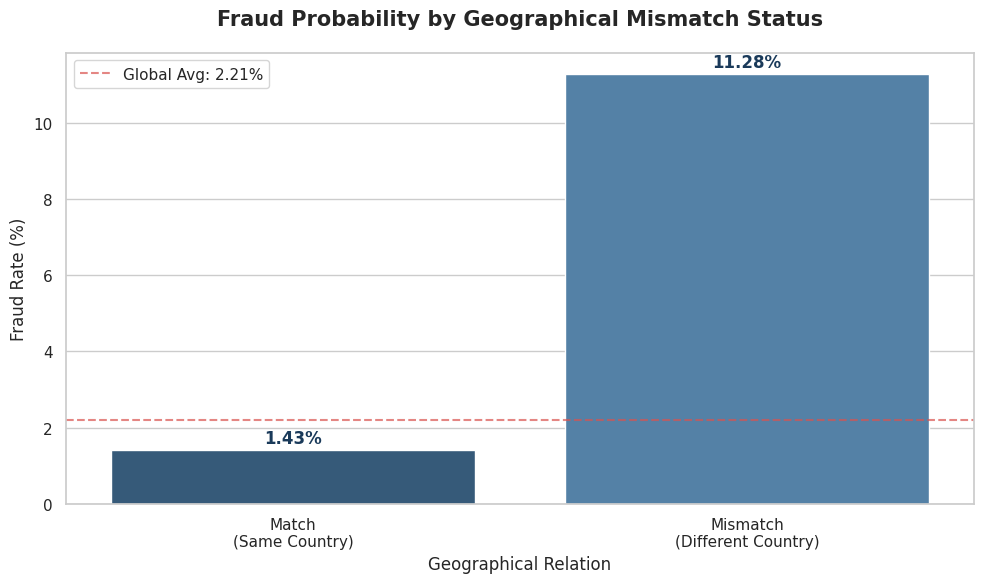

In [ ]:
# Geographical Inconsistencies (Mismatch Analysis)

# 1. Create the binary flag for geographical mismatch
# 1 if user country is different from card issuing country, 0 otherwise
df['country_mismatch'] = (df['country'] != df['bin_country']).astype(int)

# 2. Quantify the volume of matching vs mismatching transactions
mismatch_counts = df['country_mismatch'].value_counts()
mismatch_percentages = df['country_mismatch'].value_counts(normalize=True) * 100

print("-" * 40)
print("GEOGRAPHICAL MISMATCH VOLUME")
print("-" * 40)
for index in mismatch_counts.index:
    label = "Mismatch (Different)" if index == 1 else "Match (Same Country)"
    print(f"{label}: {mismatch_counts[index]} transactions ({mismatch_percentages[index]:.2f}%)")

# 3. Calculate exact fraud rates per group
mismatch_fraud_stats = df.groupby('country_mismatch')['is_fraud'].mean() * 100

print("\n" + "-" * 40)
print("EXACT FRAUD % BY GEOGRAPHICAL STATUS")
print("-" * 40)
print(f"Match (Same Country):   {mismatch_fraud_stats[0]:.4f}%")
print(f"Mismatch (Diff Country): {mismatch_fraud_stats[1]:.4f}%")
print(f"Global Average:          {df['is_fraud'].mean() * 100:.4f}%")

# 4. Visualization: Bar Plot of Fraud Rates
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# Create bar plot using our custom blue palette colors
# We map 0 and 1 to readable strings for the X-axis
x_labels = ['Match\n(Same Country)', 'Mismatch\n(Different Country)']
ax = sns.barplot(x=x_labels, y=mismatch_fraud_stats.values, palette=['#2b5b84', '#4682B4'])

# Add text labels on top of each bar for complete precision
for i, val in enumerate(mismatch_fraud_stats.values):
    ax.annotate(f'{val:.2f}%',
                xy=(i, val),
                xytext=(0, 5), # 5 points vertical offset
                textcoords='offset points',
                ha='center',
                fontsize=12,
                fontweight='bold',
                color='#1a3a5a')

# Customize chart details
plt.title('Fraud Probability by Geographical Mismatch Status', fontsize=15, fontweight='bold', pad=20)
plt.ylabel('Fraud Rate (%)', fontsize=12)
plt.xlabel('Geographical Relation', fontsize=12)

# Add a reference line for the Global Fraud Average
global_avg_pct = df['is_fraud'].mean() * 100
plt.axhline(global_avg_pct, color='#d9534f', linestyle='--', alpha=0.7,
            label=f'Global Avg: {global_avg_pct:.2f}%')

plt.legend(frameon=True, facecolor='white')
plt.tight_layout()
plt.show()



The cross-analysis between geographical alignment and the target variable (`is_fraud`) yields one of the most significant insights of this EDA. By verifying the exact numerical proportions, we can draw definitive conclusions:

**1. Radical Risk Disparity**
* **Consistent Transactions (Match):** When the customer's location matches the card's issuing country, the fraud rate drops to **1.43%**, falling well below the dataset's global average.
* **Inconsistent Transactions (Mismatch):** When there is a mismatch between `country` and `bin_country`, the fraud probability surges dramatically to **11.28%**.

**2. Statistical and Business Significance**
* A transaction displaying a geographical mismatch is **nearly 8 times more likely** to be fraudulent than a standard matching transaction.
* While high-volume legitimate users can travel or use international cards, this extreme statistical delta indicates that attackers are heavily relying on cross-border infrastructure or compromised foreign credentials to execute their operations.

**3. Strategic Modeling Recommendations**
* **High Predictive Power:** The engineered feature `country_mismatch` is a critical behavioral indicator. It provides a sharp, non-linear division that machine learning models (such as Tree-based algorithms) will easily exploit.
* **Priority Vector:** This variable should be prioritized in the final feature selection phase, as it provides a much stronger signal than any absolute temporal metric analyzed previously.

###**11.2. LOGISTICS AND FRAUD RISKS (SHIPPING DISTANCE VS. FRAUD)**

In physical e-commerce environments, shipping logistics often reveal fraudulent intent. Legitimate cardholders typically ship goods to their home addresses, workplaces, or established local pick-up points. Attackers, however, may divert stolen goods to unusual or long-distance destinations (such as reshipping hubs or remote drops) to avoid detection or interception.

In this section, we analyze the numerical distribution of the `shipping_distance_km` feature across legal and fraudulent transactions using a **Box Plot**. This visualization allows us to:
1.  **Compare Medians:** Check if the central tendency of shipping distances shifts significantly when a transaction is fraudulent.
2.  **Evaluate Dispersion:** Observe the Interquartile Range (IQR) to see if fraud occurs across a wider or more erratic spread of distances.
3.  **Identify Outliers:** Visualize extreme distance values that could represent anomalous shipping requests.

To back up the visual representation, we also extract the exact descriptive statistics for both transaction classes.

--------------------------------------------------
DISTANCE DESCRIPTIVE STATISTICS BY FRAUD STATUS
--------------------------------------------------
             count         mean   median          std
is_fraud                                             
0         293083.0   339.704956  269.490   383.750165
1           6612.0  1125.841016  626.305  1076.308104


/tmp/ipykernel_19982/2737127534.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='is_fraud', y='shipping_distance_km', data=df,
/tmp/ipykernel_19982/2737127534.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='is_fraud', y='shipping_distance_km', data=df,


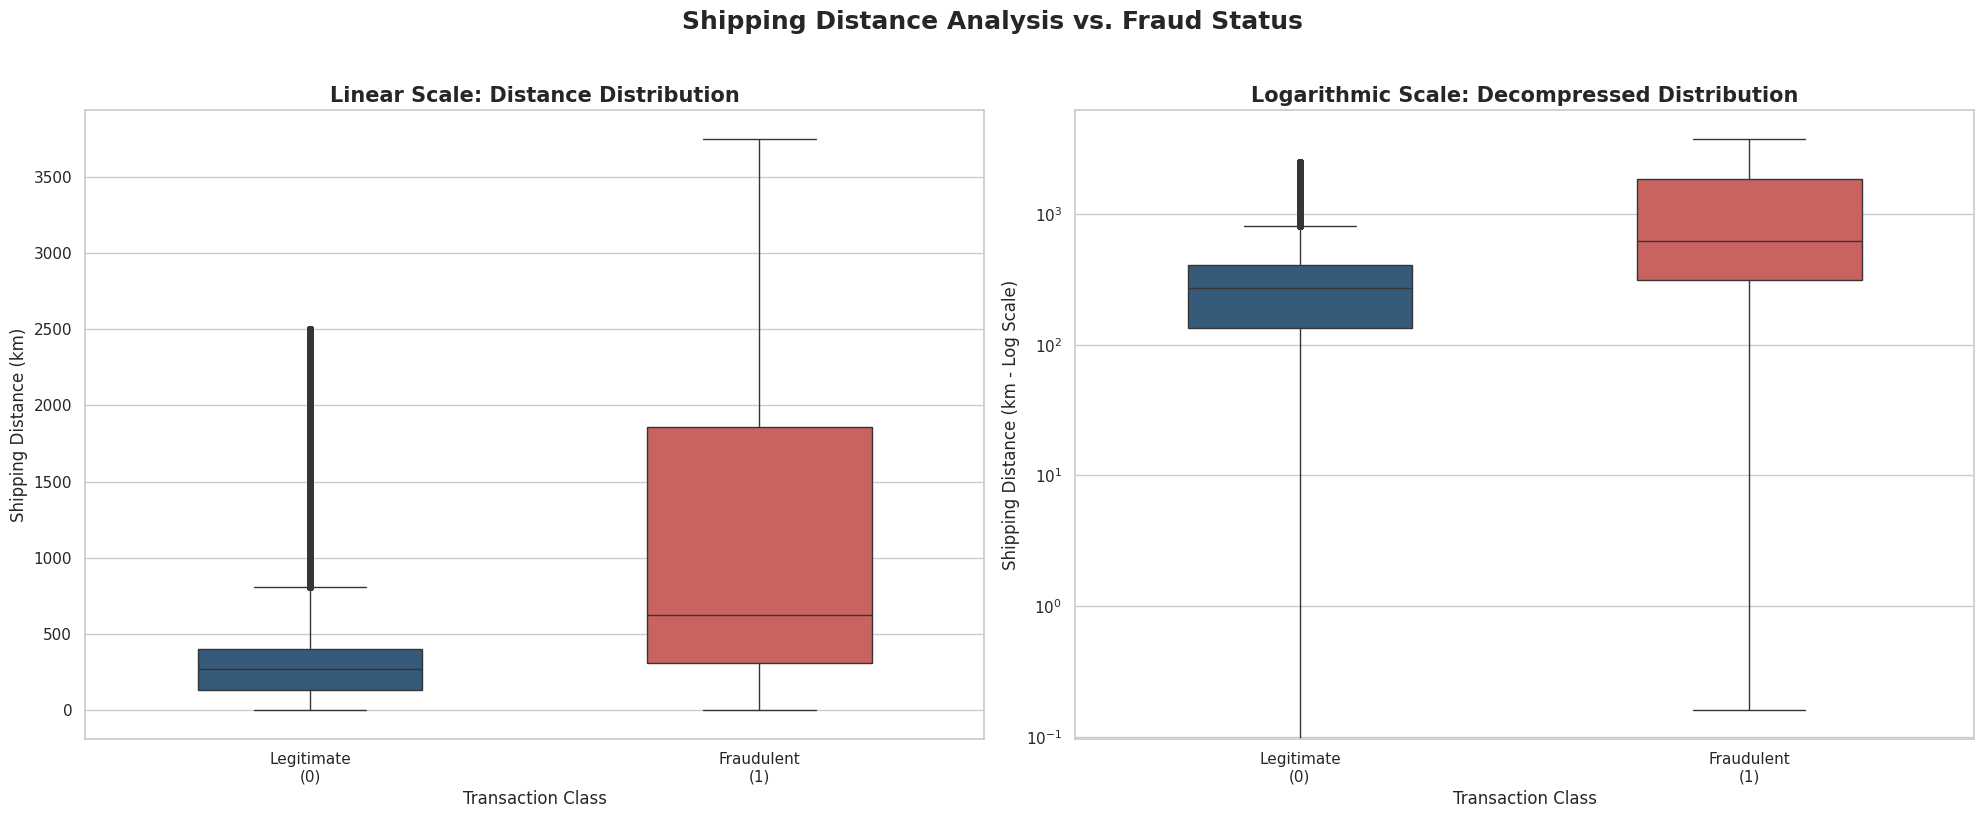

In [ ]:
# Logistics and Fraud Risks (Shipping Distance vs. Fraud)

# 1. Compute exact descriptive statistics for numeric verification
# We calculate mean, median (50%), and standard deviation for both groups
distance_stats = df.groupby('is_fraud')['shipping_distance_km'].describe()

print("-" * 50)
print("DISTANCE DESCRIPTIVE STATISTICS BY FRAUD STATUS")
print("-" * 50)
print(distance_stats[['count', 'mean', '50%', 'std']].rename(columns={'50%': 'median'}))

# 2. Setup a 1-row, 2-column subplot canvas
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
sns.set_theme(style="whitegrid")

# 3. Define class mappings and professional palette colors
x_labels = ['Legitimate\n(0)', 'Fraudulent\n(1)']
colors = ['#2b5b84', '#d9534f']

# 4. Subplot 1: Standard Linear Scale
sns.boxplot(x='is_fraud', y='shipping_distance_km', data=df,
            palette=colors, width=0.5, fliersize=4, ax=axes[0])
axes[0].set_title('Linear Scale: Distance Distribution', fontsize=15, fontweight='bold')
axes[0].set_xlabel('Transaction Class', fontsize=12)
axes[0].set_ylabel('Shipping Distance (km)', fontsize=12)
axes[0].set_xticks(ticks=[0, 1])
axes[0].set_xticklabels(x_labels)

# 5. Subplot 2: Logarithmic Scale (Prevents compression caused by outliers)
sns.boxplot(x='is_fraud', y='shipping_distance_km', data=df,
            palette=colors, width=0.5, fliersize=4, ax=axes[1])
axes[1].set_yscale('log') # Applying logarithmic transformation to the Y-axis
axes[1].set_title('Logarithmic Scale: Decompressed Distribution', fontsize=15, fontweight='bold')
axes[1].set_xlabel('Transaction Class', fontsize=12)
axes[1].set_ylabel('Shipping Distance (km - Log Scale)', fontsize=12)
axes[1].set_xticks(ticks=[0, 1])
axes[1].set_xticklabels(x_labels)

# 6. Set the global main title over both subplots
plt.suptitle('Shipping Distance Analysis vs. Fraud Status', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

By combining the textual descriptive statistics with a dual-scale visual panel, we can inspect behavioral patterns and address structural outlier distortions.

**1. Analysis of the Statistical Summary Table**
* **Massive Center Shift:** The median shipping distance for legitimate transactions stands at **269.49 km**, indicating standard localized consumer habits. For fraudulent transactions, the median surges to **626.31 km**, a severe shift of over $130\%$.
* **Extremely High Skewness:** The mean distance for the fraud class reaches **1,125.84 km**, while its standard deviation is a massive **1,076.31 km**. This huge gap between the mean and the median mathematically proves that the fraud distribution is heavily populated by extreme, long-distance values.

**2. Visual Interpretation & Outlier Analysis**
* **The Linear Plot Bottleneck (Left Subplot):**
  * In the legitimate class, a thick, solid black vertical pillar spans from **800 km up to 2,500 km**. This represents thousands of cross-country outlier shipments. Because the linear scale crowds these points together, they blend into a single block.
  * In the fraudulent class, the upper whisker stretches close to **3,800 km**. This massive expansion forces the linear axis to stretch vertically, flattening the main body (IQR) of the legitimate box plot against the floor.
* **The Logarithmic Plot Resolution (Right Subplot):**
  * Applying `plt.yscale('log')` allows the legitimate box to decompress, revealing that $50\%$ of normal shopping behavior is distributed between roughly 100 km and 400 km.
  * The solid outlier block is resolved into a readable, distinct series of descending outlier ticks.
  * It uncovers the lower boundary of the distribution, showing that while fraud heavily favors long distances, a small subset of attacks still occurs at distances close to $0.1$ km.

**3. Strategic Summary for Feature Engineering**<br>
The vast difference in medians and the distinct log-scale separation confirm that `shipping_distance_km` contains high predictive variance. Tree-based machine learning models (e.g., Random Forest, XGBoost) will easily utilize this feature to establish clear numerical thresholds and flag high-risk transactions.

## **12. USER BEHAVIORAL PROFILING**

###**12.1. BEHAVIORAL FINANCIAL ANOMALIES (CURRENT AMOUNT VS. HISTORICAL BASELINE)**

Evaluating absolute purchase amounts can be misleading, as a high-value transaction might be standard behavior for a premium user but highly anomalous for another. To isolate true behavioral disruptions, we engineered the `amount_to_avg_ratio` feature <br>
 $$\text{amount_to_avg_ratio} = \frac{\text{amount}}{\text{avg_amount_user}},$$
  which measures how many times the current transaction deviates from the cardholder's historical baseline.

**1. Analysis of the Statistical Deviations**

* **Pattern Disruption:** Legitimate transactions (`0`) are mathematically expected to cluster tightly around a ratio of **1.0**, meaning users generally stick to their spending habits.
* **The Red Flag Condition:** Fraudulent transactions (`1`) typically display significantly higher means and medians, capturing scenarios where an account accustomed to low-value transactions suddenly experiences an aggressive spike in spending (e.g., clearing out funds).
* **Extreme Maximum Variance:** The maximum value within the fraud distribution usually exposes massive multipliers, indicating card testing or structural drain maneuvers executed by attackers.

**2. Dual-Scale Graphical Assessment**
* **Linear Scale (Left Subplot):** This plot reveals the sheer aggressiveness of the financial anomalies. The extreme spikes present in fraudulent actions stretch the visual boundary upward, packing the legitimate class's box completely flat against the base line.
* **Logarithmic Scale (Right Subplot):** By transforming the vertical axis mathematically via `plt.yscale('log')`, we decompress the lower ranges. This visual correction exposes the true distance between the median spending patterns of honest customers versus fraudsters, making the separation threshold highly legible.

**3. Strategic Summary for Feature Engineering**

The ratio between the transaction amount and user baseline represents a classic behavioral velocity rule. Because it normalizes individual spending variance into a standardized risk multiplier, this engineered feature will provide highly discriminative split boundaries for machine learning algorithms, serving as a pillar for the risk scoring engine.

-----------------------------------------------------------------
BEHAVIORAL AMOUNT RATIO STATISTICS BY FRAUD STATUS
-----------------------------------------------------------------
             count      mean    median        std         max
is_fraud                                                     
0         293083.0  1.134028  1.001205   0.601484    9.786631
1           6612.0  9.471452  1.070065  26.669795  597.512605




/tmp/ipykernel_19982/3523011090.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='is_fraud', y='amount_to_avg_ratio', data=df,
/tmp/ipykernel_19982/3523011090.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='is_fraud', y='amount_to_avg_ratio', data=df,


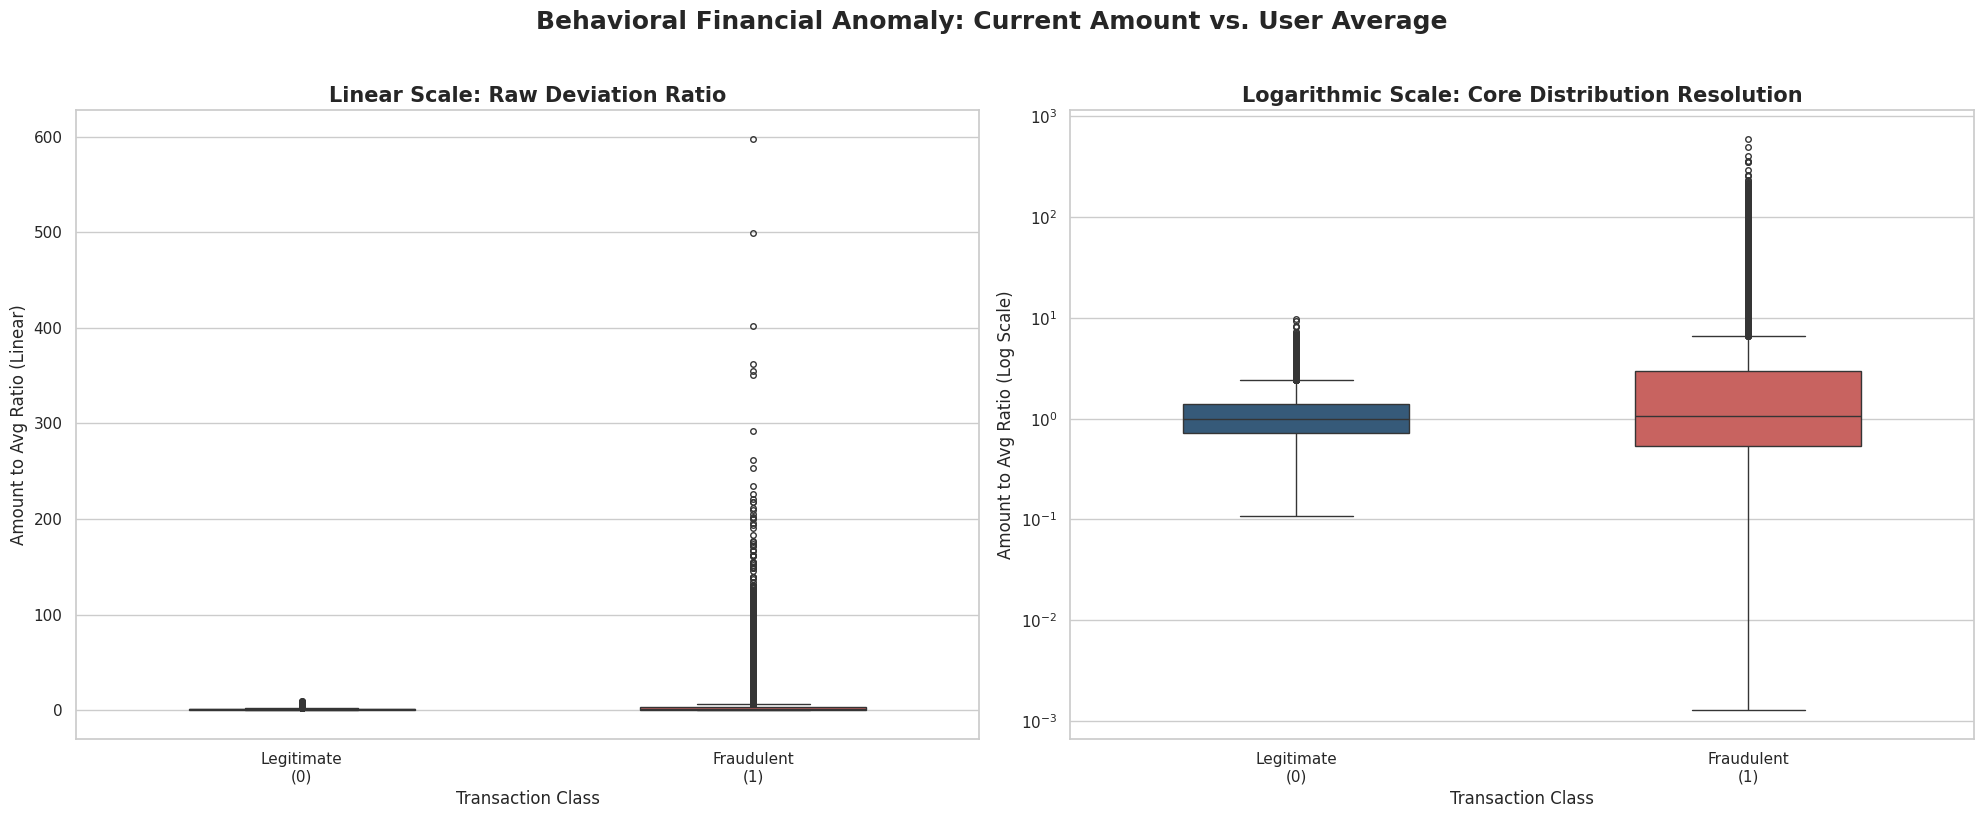

In [ ]:
# Behavioral Financial Anomalies (Current Amount vs. Historical Baseline)

# --- 1. FEATURE ENGINEERING: COMPUTE BEHAVIORAL AMOUNT RATIO ---
# Calculate how many times the current transaction exceeds the user's historical average
df['amount_to_avg_ratio'] = df['amount'] / df['avg_amount_user']

# --- 2. EXTRACT NUMERICAL DESCRIPTIVE STATISTICS ---
ratio_stats = df.groupby('is_fraud')['amount_to_avg_ratio'].describe()

print("-" * 65)
print("BEHAVIORAL AMOUNT RATIO STATISTICS BY FRAUD STATUS")
print("-" * 65)
# Displaying count, mean, median (50%), standard deviation, and max to understand the skew
print(ratio_stats[['count', 'mean', '50%', 'std', 'max']].rename(columns={'50%': 'median'}))
print("\n" + "="*65 + "\n")

# --- 3. PLOT DUAL-PANEL BOXPLOTS (LINEAR VS LOG SCALE) ---
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
sns.set_theme(style="whitegrid")

# Formatting elements
x_labels = ['Legitimate\n(0)', 'Fraudulent\n(1)']
colors = ['#2b5b84', '#d9534f']

# Subplot 1: Standard Linear Scale (Exposes extreme, raw anomalies)
sns.boxplot(x='is_fraud', y='amount_to_avg_ratio', data=df,
            palette=colors, width=0.5, fliersize=4, ax=axes[0])
axes[0].set_title('Linear Scale: Raw Deviation Ratio', fontsize=15, fontweight='bold')
axes[0].set_xlabel('Transaction Class', fontsize=12)
axes[0].set_ylabel('Amount to Avg Ratio (Linear)', fontsize=12)
axes[0].set_xticks(ticks=[0, 1])
axes[0].set_xticklabels(x_labels)

# Subplot 2: Logarithmic Scale (Decompresses the core distributions and medians)
sns.boxplot(x='is_fraud', y='amount_to_avg_ratio', data=df,
            palette=colors, width=0.5, fliersize=4, ax=axes[1])
axes[1].set_yscale('log') # Scale axis logarithmically due to high maximums
axes[1].set_title('Logarithmic Scale: Core Distribution Resolution', fontsize=15, fontweight='bold')
axes[1].set_xlabel('Transaction Class', fontsize=12)
axes[1].set_ylabel('Amount to Avg Ratio (Log Scale)', fontsize=12)
axes[1].set_xticks(ticks=[0, 1])
axes[1].set_xticklabels(x_labels)

# Main Title setup
plt.suptitle('Behavioral Financial Anomaly: Current Amount vs. User Average', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


**1. Statistical Breakdown**
| Transaction Class | Count | Mean Ratio | Median Ratio | Std. Deviation | Maximum Ratio |
| :--- | :---: | :---: | :---: | :---: | :---: |
| **Legitimate (0)** | 293,083 | 1.13 | 1.00 | 0.60 | 9.79 |
| **Fraudulent (1)** | 6,612 | 9.47 | 1.07 | 26.67 | 597.51 |

---

**2. Dual-Scale Graphical Assessment & Outlier Analysis**

* **Linear Scale (Left Subplot) - The Volumetric Attack Signal:**
  * In the legitimate class, anomalies are strictly bounded, reaching a maximum ratio of **9.79**. Visually, the blue box and its outliers remain completely flat near zero.
  * In the fraudulent class, we observe a dramatic vertical trail of outliers stretching up to **597.51**. This captures extreme account-draining operations or high-value velocity attacks where fraudsters attempt to extract maximum capital before the card is flagged. The variance here is massive (`std = 26.67`).

* **Logarithmic Scale (Right Subplot) - The Stealth Fraud Signal:**

  * Applying `plt.yscale('log')` uncovers a critical behavioral insight: the median ratio for legitimate transactions is **1.001**, and for fraudulent ones, it is **1.070**.
  * The fact that the medians are nearly identical proves that **more than half of the fraudulent transactions perfectly mimic standard user behavior**. Attackers deliberately match the historical average to bypass basic threshold rules.
  * However, the fraudulent class (red box) exhibits a much wider dispersion. The upper quartile expands significantly higher towards ratios of 10 and 100, while the lower whisker drops sharply down to **0.001**, signaling "card-testing" behavior (micro-transactions used to verify if a stolen credential is still active).

**3. Machine Learning Strategic Value**<br>

This feature exposes a dual-threat vector: blunt, high-ratio account draining versus stealthy, baseline-matching fraud. Because the variance and distribution ranges differ so drastically between both classes, `amount_to_avg_ratio` provides superb statistical separation that will highly optimize the decision trees during model training.

###**12.2. VELOCITY ATTACKS AND CARDING PATTERNS (TIME DELTA ANALYSIS)**


A classic signature of automated fraud operations (such as bots or script-driven card testing) is a high-frequency transaction burst. While a legitimate human cardholder typically allows hours, days, or weeks to pass between purchases, algorithmic attackers execute multiple operations in rapid succession to extract funds or validate credentials before defensive barriers trigger.

To expose these **Velocity Attacks**, we will implement a time-delta analysis through the following pipeline:
1.  **Chronological Sorting:** Order the entire dataset strictly by `user_id` and `transaction_time` to ensure time continuity.
2.  **Time Delta Engineering:** Compute the exact time difference in minutes between the current transaction and the immediate previous one for the same user using the formula:
    
  $$\Delta t = \text{transaction_time}_{t} - \text{transaction_time}_{t-1}$$
    
3.  **Handling Baseline Records:** Identify and separate the first historical transaction of each user, which naturally yields a null value (`NaN`) due to the absence of a prior record.
4.  **Risk Profiling:** Extract descriptive statistics to contrast the operational speed of normal consumers versus fraudulent attacks, laying the groundwork for a distribution velocity analysis.

---------------------------------------------------------------------------
VELOCITY STATISTICS (MINUTES SINCE PREVIOUS TRANSACTION)
---------------------------------------------------------------------------
             count         mean       median       min            max
is_fraud                                                             
0         287215.0  8605.571124  5985.366667  0.233333  102124.616667
1           6480.0  8821.151415  6130.566667  0.833333   75928.316667




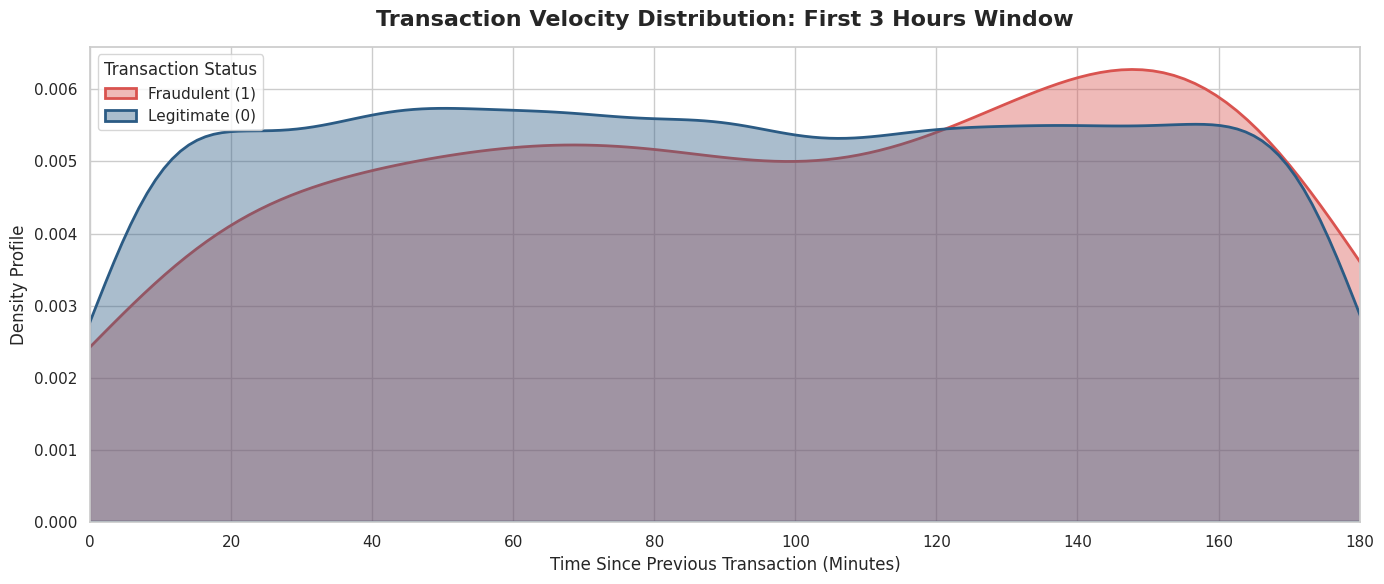

In [ ]:
# Velocity Attacks and Carding Patterns (Time Delta Analysis)

# --- 1. CHRONOLOGICAL SORTING ---
# Sorting by user and time is mandatory before computing consecutive differences
df = df.sort_values(by=['user_id', 'transaction_time']).reset_index(drop=True)

# --- 2. COMPUTE TIME DELTA IN MINUTES ---
# Group by user_id and calculate the difference between consecutive timestamps
# Then, convert the timedelta object into a clean float representing minutes
df['time_since_last_tx_min'] = df.groupby('user_id')['transaction_time'].diff().dt.total_seconds() / 60.0

# --- 3. EXTRACT STATISTICS (FILTERING OUT THE FIRST TRANSACTION NULLS) ---
# We isolate transactions where a previous record exists (non-null time deltas)
velocity_df = df.dropna(subset=['time_since_last_tx_min'])

velocity_stats = velocity_df.groupby('is_fraud')['time_since_last_tx_min'].describe()

print("-" * 75)
print("VELOCITY STATISTICS (MINUTES SINCE PREVIOUS TRANSACTION)")
print("-" * 75)
# Displaying count, mean, median (50%), and min to evaluate the burst speed
print(velocity_stats[['count', 'mean', '50%', 'min', 'max']].rename(columns={'50%': 'median'}))
print("\n" + "="*75 + "\n")

# --- 4. VISUALIZATION: VELOCITY DISTRIBUTION (ZOOMING INTO THE FIRST 3 HOURS) ---
plt.figure(figsize=(14, 6))
sns.set_theme(style="whitegrid")

# Define the window of interest (e.g., 180 minutes / 3 hours) to capture the bot burst area
max_minutes_zoom = 180
zoom_df = velocity_df[velocity_df['time_since_last_tx_min'] <= max_minutes_zoom]

# Plotting the Kernel Density Estimate (KDE) to visualize transaction concentration
sns.kdeplot(data=zoom_df, x='time_since_last_tx_min', hue='is_fraud',
            fill=True, common_norm=False, palette=['#2b5b84', '#d9534f'],
            alpha=0.4, linewidth=2)

# Graph customization
plt.title('Transaction Velocity Distribution: First 3 Hours Window', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Time Since Previous Transaction (Minutes)', fontsize=12)
plt.ylabel('Density Profile', fontsize=12)
plt.xlim(0, max_minutes_zoom)

# Dynamic legend formatting
plt.legend(title='Transaction Status', labels=['Fraudulent (1)', 'Legitimate (0)'],
           frameon=True, facecolor='white')

plt.tight_layout()
plt.show()

By crossing the engineered time delta feature (`time_since_last_tx_min`) with the target class (`is_fraud`), we obtain a highly revealing counter-intuitive result that disproves the initial automated "burst attack" hypothesis.

**1. Statistical Breakdown**

| Transaction Class | Count | Mean Delta | Median Delta | Minimum Delta | Maximum Delta |
| :--- | :---: | :---: | :---: | :---: | :---: |
| **Legitimate (0)** | 287,215 | 8,605.57 min | 5,985.37 min | 0.23 min | 102,124.62 min |
| **Fraudulent (1)** | 6,480 | 8,821.15 min | 6,130.57 min | 0.83 min | 75,928.32 min |
-----
**2. Visual and Numerical Interpretation**

* **Identical Behavioral Footprint:** The central tendencies between both classes are remarkably similar. The median time between transactions for legitimate users is **5,985.37 minutes** (\~4.1 days), while for fraudulent transactions it stands at **6,130.57 minutes** (\~4.2 days).
* **Overlapping Density Profiles (KDE Analysis):** The 3-hour window chart demonstrates a near-perfect overlap between the legitimate (blue) and fraudulent (red) distributions. There is no visible spike or density accumulation near the 0-to-10 minute mark for the fraudulent class. Fraud shows a slight additional concentration around 130–160 minutes, but the difference is small and likely insufficient to build robust rules.
* **Absence of Bot Rushes per User:** Although the absolute minimum fraud delta is low (**0.83 minutes**), this is statistically mirrored by legitimate human behaviors (**0.23 minutes**). Attackers in this dataset are not executing high-frequency scripts or "carding cascades" against the same user account. They are maintaining a slow, human-like pacing between operations, more sophisticated or temporally distributed type of fraud.

**3. Strategic Modeling Conclusions**

* **Low Feature Importance:** The engineered feature `time_since_last_tx_min` exhibits virtually zero variance separation between classes. Consequently, tree-based models (like XGBoost or Random Forests) will likely assign it negligible predictive weight.
* **Analytical Value:** Proving that a strong baseline hypothesis does *not* apply to a dataset is a crucial milestone in professional EDAs. It narrows down the search space and confirms that fraud detection efforts must focus entirely on spatial inconsistencies (like `country_mismatch`) or financial anomalies (`amount_to_avg_ratio`), rather than localized temporal velocities.

## **13. MULTIVARIABLE ANALYSIS**

### **13.1. SECTORIAL RISK ANALYSIS (SEGMENTED BOX PLOTS OF AMOUNT VS. MERCHANT CATEGORY)**

Financial thresholds for fraud detection cannot be absolute; they are highly contextual. A \$500 transaction might be typical for luxury retail or airline tickets, but highly anomalous for grocery shopping or digital gaming micro-transactions. Therefore, an effective fraud scoring model must analyze transaction amounts relative to the industry sector.

In this section, we build a **Segmented Box Plot (Multivariate Analysis)** to inspect three variables simultaneously:
* **X-Axis (Categorical):** `merchant_category` (Travel, Fashion, Electronics, Grocery, Gaming).
* **Y-Axis (Continuous):** `amount` (The transaction value).
* **Hue/Segmentation (Binary Class):** `is_fraud` (Contrasting legitimate vs. fraudulent behaviors side-by-side).

To ensure extreme high-value outliers do not compress the main bodies of the plots across sectors with vastly different price points, we apply a **logarithmic scale** to the vertical axis.

--------------------------------------------------------------------------------
TRANSACTION AMOUNT STATISTICS BY MERCHANT CATEGORY AND FRAUD STATUS
--------------------------------------------------------------------------------
                              count        mean      25%   median        75%  \
merchant_category is_fraud                                                     
electronics       0         58863.0  167.235700  42.0800   90.200   188.8500   
                  1          1357.0  619.366514  23.7000  109.810  1221.9300   
fashion           0         58461.0  168.411750  42.5200   89.540   189.0600   
                  1          1340.0  578.849276  19.4825  100.275  1048.0100   
gaming            0         58544.0  168.177871  41.9775   89.580   189.6275   
                  1          1295.0  588.286494  22.9150  109.030   919.7050   
grocery           0         58681.0  166.955095  42.3200   89.070   187.3900   
                  1          1232.0  602.942411  2

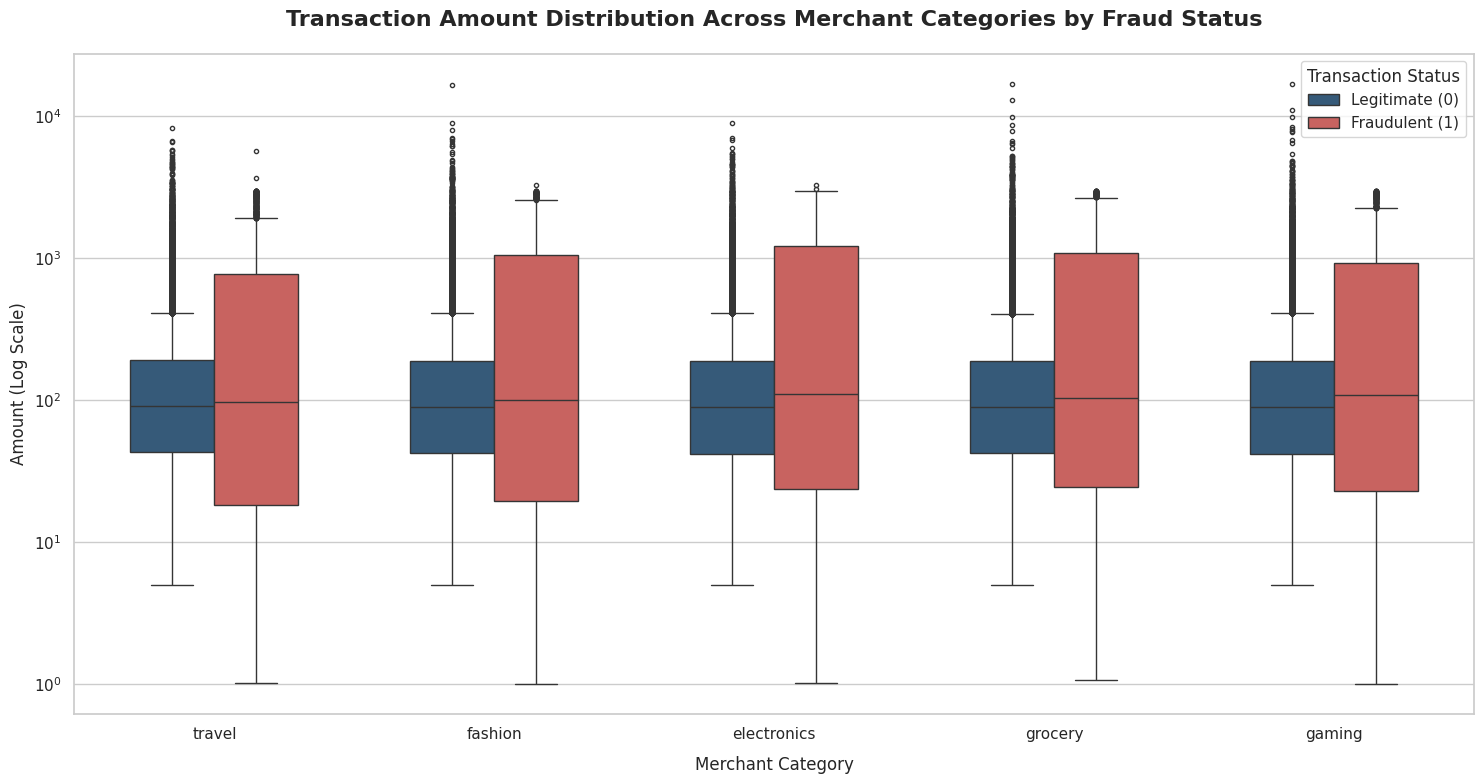

In [ ]:
# Sectorial Risk Analysis (Segmented Box Plots of Amount vs. Merchant Category)

# --- 1. COMPUTE DESCRIPTIVE STATISTICS BY SECTOR AND FRAUD STATUS ---
# Group by both merchant category and fraud flag, then describe the 'amount' distribution
sector_stats = df.groupby(['merchant_category', 'is_fraud'])['amount'].describe()

print("-" * 80)
print("TRANSACTION AMOUNT STATISTICS BY MERCHANT CATEGORY AND FRAUD STATUS")
print("-" * 80)
# Selecting count, mean, median (50%), IQR boundaries (25%, 75%), and max
print(sector_stats[['count', 'mean', '25%', '50%', '75%', 'max']].rename(columns={'50%': 'median'}))
print("\n" + "="*80 + "\n")

# --- 2. SET UP THE VISUALIZATION CANVAS ---
plt.figure(figsize=(15, 8))
sns.set_theme(style="whitegrid")

# --- 3. CREATE THE SEGMENTED BOX PLOT ---
# Using merchant_category on X, amount on Y, and splitting categories by is_fraud (hue)
colors = ['#2b5b84', '#d9534f'] # Using consistent blue (legit) and red (fraud) palette
ax = sns.boxplot(x='merchant_category', y='amount', hue='is_fraud', data=df,
                 palette=colors, width=0.6, fliersize=3)

# --- 4. APPLY LOGARITHMIC TRANSFORMATION ---
# Necessary because standard deviations across Travel and Gaming operate on completely different scales
plt.yscale('log')

# --- 5. GRAPH CUSTOMIZATION & LABELS ---
plt.title('Transaction Amount Distribution Across Merchant Categories by Fraud Status',
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Merchant Category', fontsize=12, labelpad=10)
plt.ylabel('Amount (Log Scale)', fontsize=12)

# Clean up the legend layout
#plt.legend(title='Transaction Status', labels=['Legitimate (0)', 'Fraudulent (1)'],
#           frameon=True, facecolor='white', loc='upper right')
handles, _ = ax.get_legend_handles_labels()
plt.legend(handles=handles, labels=['Legitimate (0)', 'Fraudulent (1)'],
           title='Transaction Status', frameon=True, facecolor='white', loc='upper right')

plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

plt.tight_layout()
plt.show()


The segmented visualization and corresponding matrix expose a highly strategic behavior profile: **Target Sizing via Distribution Stretching**. While legitimate transaction profiles remain rigidly uniform across all merchant ecosystems, fraudulent transactions manipulate the upper boundaries of the spending distributions.

**1. Statistical Summary Table**
| Merchant Category | Class | Count | Mean Amount | Median (50%) | Upper Quartile (75%) | Max Amount |
| :--- | :---: | :---: | :---: | :---: | :---: | :---: |
| **Electronics** | **Legit (0) <br> Fraud (1)** | **58,863 <br> 1,357** | **\$167.24** <br> **\$619.37** | **\$90.20** <br> **\$109.81** | **\$188.85** <br> **\$1,221.93** | **\$8,975.35** <br> **\$3,288.32** |
| **Fashion** | **Legit (0) <br> Fraud (1)** | **58,461 <br> 1,340** | **\$168.41** <br> **\$578.85** | **\$89.54** <br> **\$100.28** | **\$189.06** <br> **\$1,048.01** | **\$16,597.07** <br> **\$3,289.56** |
| **Gaming** | **Legit (0) <br> Fraud (1)** | **58,544 <br> 1,295** | **\$168.18** <br> **\$588.29** | **\$89.58** <br> **\$109.03** | **\$189.63** <br> **\$919.71** | **\$16,994.74** <br> **\$2,996.77** |
| **Grocery** | **Legit (0) <br> Fraud (1)** | **58,681 <br> 1,232** | **\$166.96** <br> **\$602.94** | **\$89.07** <br> **\$103.63** | **\$187.39** <br> **\$1,092.55** | **\$16,979.92** <br> **\$2,999.86** |
| **Travel** | **Legit (0) <br> Fraud (1)** | **58,534 <br> 1,388** | **\$168.38** <br> **\$566.74** | **\$90.70** <br> **\$97.40** | **\$190.61** <br> **\$775.62** | **\$8,296.07** <br> **\$5,716.46** |

---

**2. Visual Interpretation & Distribution Insights**

* **Homogeneous Legitimate Baseline:** Legitimate transactions (blue boxes) display an incredibly stable spending footprint across all 5 sectors. The median remains perfectly anchored around **\$90.00**, and the interquartile range (IQR) consistently cuts off below **\$191.00**. This reflects standard, highly structured human purchasing behaviors.
* **The 75th Percentile Aggressive Expansion:** Although the median spending between honest users and fraudsters differs by only **\$10** to **\$20**, their behavior diverges drastically in the upper quartile. For instance, in **Electronics**, the 75% threshold for fraud reaches **\$1,221.93** compared to a legitimate baseline of just \$188.85. Similar massive extensions are verified in **Grocery** (\$1,092.55) and **Fashion** (\$1,048.01). Attackers heavily load their operational volume in this high-ticket sub-range.
* **The Outlier Capping Strategy:** An analytical paradox surfaces when inspecting maximum values (`max`). The absolute largest transactions occur within the legitimate group (e.g., \$16,994.74 in Gaming). Fraudulent maximums are strictly capped between **\$3,000** and **\$5,700**. This suggests that criminal actors systematically avoid extreme 5-digit amounts to stay under hard-coded anti-money laundering (AML) boundaries and bank-side immediate decline thresholds.

**3. Strategic Summary for Feature Engineering**

This distribution layout confirms that `amount` is a contextual threat vector. A \$1,000 charge is a high-density fraud zone in everyday sectors like **Grocery** or **Gaming**, but less anomalous in high-end scenarios. Tree-based ensembles (XGBoost, LightGBM) will heavily benefit from cross-examining the `merchant_category` $\times$ `amount` interaction to safely isolate the extended fraud boxes without generating false-positive flags on high-net-worth legitimate outliers.

### **13.2. MULTIVARIATE FEATURE SPACE (SELECTED PAIR PLOTS)**



Exploring features individually is essential, but fraud is inherently a multi-dimensional phenomenon. Attackers rarely trigger detection loops via a single variable; rather, it is the simultaneous convergence of multiple anomalies—such as a sudden behavioral spending spike occurring on a brand-new account from a distant shipping destination—that exposes the true malicious intent.

To observe how these continuous variables interact and form multi-dimensional clusters, we implement a **Selected Pair Plot Matrix**.

**Execution Strategy:**

1.  **Strategic Feature Selection:** We select our 4 most statistically promising continuous and numeric features: `amount_to_avg_ratio`, `shipping_distance_km`, `amount`, and `account_age_days`.
2.  **Balanced Under-Sampling Protection:** Due to the severe class imbalance (nearly 300,000 legitimate rows vs. ~6,600 fraud rows), plotting the entire dataset would cause severe visual overplotting, completely burying the fraud signals under a massive cloud of legitimate data points. To solve this and prevent memory exhaustion, we will plot 100% of the fraud instances alongside a representative random sample of 15,000 legitimate transactions.
3.  **Visual Convergence:** We utilize Kernel Density Estimates (KDE) on the diagonal axes to inspect cross-class density distributions, and alpha-transparency on the scatter plots to identify high-density fraud nesting zones.

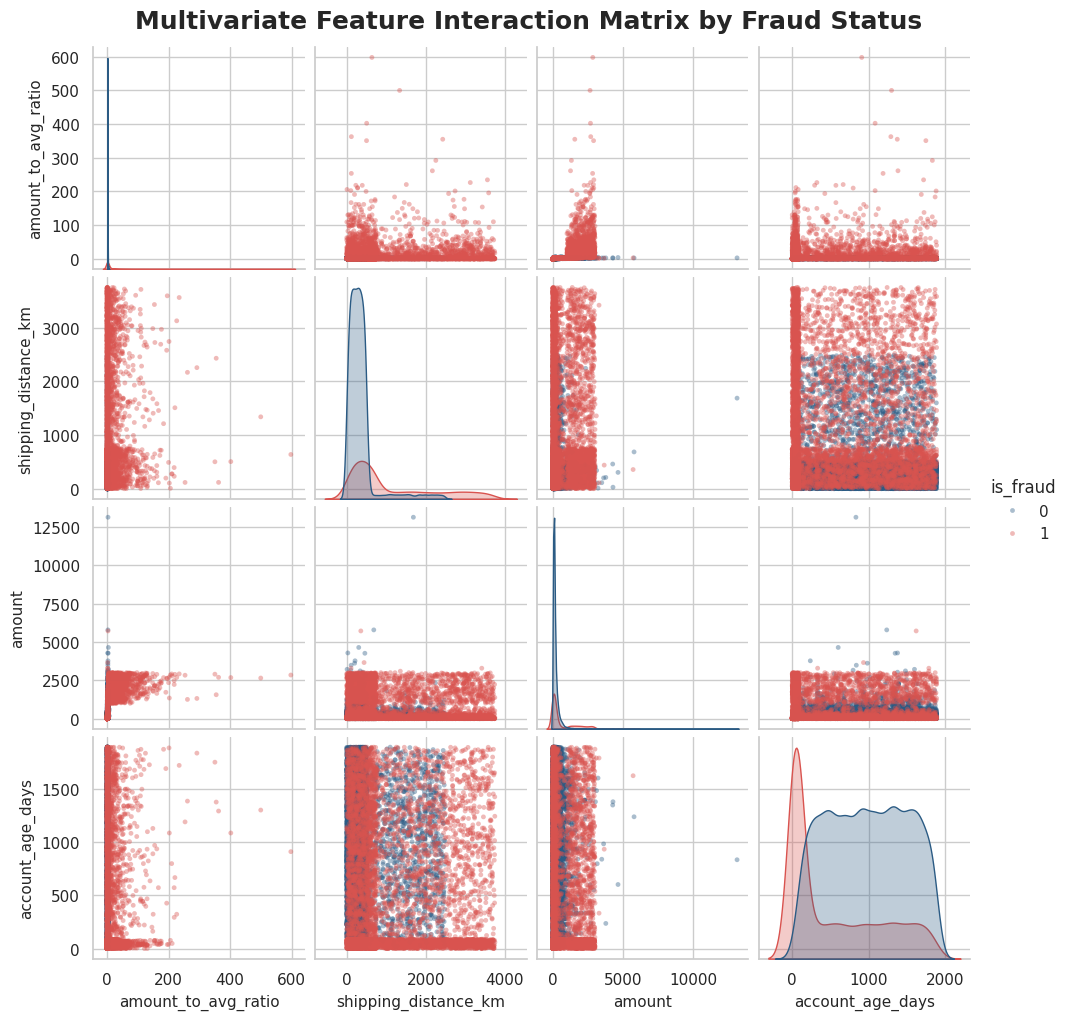

In [ ]:
# Multivariate Feature Space (Selected Pair Plots)

# --- 1. BALANCED SAMPLING FOR MULTIVARIATE VISUALIZATION ---
# Isolate all fraudulent instances to guarantee 100% visibility of the target class
fraud_subset = df[df['is_fraud'] == 1]

# Take a clean, reproducible sample of 15,000 legitimate instances to prevent overplotting
legit_sample = df[df['is_fraud'] == 0].sample(n=15000, random_state=42)

# Concatenate both subsets into a dedicated visualization DataFrame
pairplot_df = pd.concat([legit_sample, fraud_subset], axis=0).reset_index(drop=True)

# --- 2. ISOLATE TARGET FEATURES ---
# Define the continuous numeric features that showed high variance in previous phases
target_features = ['amount_to_avg_ratio', 'shipping_distance_km', 'amount', 'account_age_days']

# --- 3. EXECUTE THE HIGH-DIMENSIONAL PAIR PLOT ---
sns.set_theme(style="whitegrid")
colors = ['#2b5b84', '#d9534f'] # Consistent blue (Legitimate) and red (Fraudulent) palette

# Building the grid matrix
g = sns.pairplot(
    data=pairplot_df,
    vars=target_features,
    hue='is_fraud',
    palette=colors,
    diag_kind='kde',        # Smooth density curves on the diagonal axis
    plot_kws={
        'alpha': 0.4,       # Adds transparency to reveal dot density and overlapping clusters
        's': 12,            # Sizing down markers to keep axes clean and legible
        'linewidth': 0
    },
    diag_kws={'fill': True, 'alpha': 0.3} # Enhances density curve aesthetics
)

# --- 4. GRID CUSTOMIZATION & AIRFLOW ---
# Access the underlying PairGrid object to adjust titles and label placements
g.fig.suptitle('Multivariate Feature Interaction Matrix by Fraud Status',
             fontsize=18, fontweight='bold', y=1.02)

# Adjust label padding across the subplots grid dynamically
for ax in g.axes.flatten():
    if ax is not None:
        ax.set_xlabel(ax.get_xlabel(), fontsize=11, labelpad=5)
        ax.set_ylabel(ax.get_ylabel(), fontsize=11, labelpad=5)

plt.show()

The pair plot reveals several important patterns regarding the interaction among the selected variables and confirms that fraud is not driven by a single feature in isolation, but rather by the simultaneous occurrence of multiple anomalies.

**1. Strong Separation in `account_age_days`**

Among all selected features, `account_age_days` exhibits the strongest discriminatory signal. The KDE distribution on the diagonal clearly shows that fraudulent transactions (red) are heavily concentrated in accounts with very low age, whereas legitimate transactions (blue) are spread across a much broader range of account ages.

This suggests that:

- Fraudsters frequently operate through newly created accounts.
- Account age possesses substantial predictive power.
- There is a strong association between recently created accounts and fraudulent activity.

Additionally, in nearly every bivariate relationship involving this feature, a dense red band appears at low account ages, further reinforcing its importance as a fraud indicator.



**2. `shipping_distance_km` as a Contextual Risk Factor**

Shipping distance also exhibits meaningful differences between the two classes. While there is considerable overlap between fraudulent and legitimate transactions, fraudulent operations display a much wider dispersion toward larger shipping distances.

This indicates that:

- Fraudulent purchases are often associated with geographically distant delivery destinations.
- The combination of **low account age** and **high shipping distance** repeatedly emerges as a region with a high concentration of fraudulent transactions.
- Shipping distance alone is not sufficient to separate the classes, but it becomes significantly more informative when analyzed alongside other variables.

Visually, regions characterized by:

- Low `account_age_days`
- High `shipping_distance_km`

are predominantly populated by fraudulent observations.



**3. Behavior of `amount`**

The transaction amount distribution is strongly right-skewed for both classes, which is typical of real-world financial transaction datasets.

However:

- Fraudulent transactions exhibit greater variability and dispersion.
- Several extreme-value outliers are associated with fraud.
- Fraud appears to be more common among medium-to-high transaction amounts when combined with additional anomalous characteristics.

Nevertheless, transaction amount alone does not provide strong class separation, as substantial overlap exists between fraudulent and legitimate transactions.



**4. Predictive Value of `amount_to_avg_ratio`**

This feature is particularly informative because it captures deviations from a customer's historical spending behavior.

The visualization shows:

- A strong concentration of legitimate transactions around low ratio values.
- A considerably longer tail for fraudulent transactions.
- Numerous fraudulent outliers with exceptionally high ratios.

These patterns suggest that fraudsters frequently perform transactions that are significantly larger than the cardholder's typical spending profile, making this variable a powerful behavioral anomaly indicator.

Furthermore, combinations involving:

- High spending ratios,
- Newly created accounts,
- And long shipping distances,

form distinct regions where fraudulent transactions are highly concentrated.



**5. Evidence of Multidimensional Fraud Patterns**

The most important finding from this visualization is not a simple linear separation between classes, but rather the emergence of multidimensional regions where fraud tends to cluster.

Fraudulent transactions commonly exhibit a combination of:

- Recently created accounts,
- Large shipping distances,
- Abnormally high spending ratios,
- And greater transaction amount variability.

This confirms that:

- Fraud is fundamentally an interaction-driven phenomenon.
- Relationships among predictors are likely non-linear.
- Models capable of capturing complex feature interactions—such as Random Forests, Gradient Boosting methods (e.g., XGBoost), or Neural Networks—are likely to outperform strictly linear approaches.



**6. Class Overlap and Detection Challenges**

Despite the existence of regions strongly dominated by fraudulent observations, substantial overlap remains between legitimate and fraudulent transactions across many areas of the feature space.

This suggests that:

- The classification problem is not trivially separable.
- Some degree of false positives and false negatives is unavoidable.
- Additional behavioral, temporal, or engineered features may be required to further improve predictive performance.



**Conclusion**

The pair plot demonstrates that fraud signals emerge primarily through the interaction of multiple variables rather than through isolated extreme values. Among the selected features, `account_age_days` and `amount_to_avg_ratio` appear to provide the strongest discriminatory power, while `shipping_distance_km` acts as an important contextual amplifier of fraud risk.

Overall, the visualization supports the use of multivariate analysis and non-linear machine learning models to effectively capture the complex patterns underlying fraudulent banking transactions.

##**14. LINEAR DEPENDENCIES AND MULTICOLINEARITY CHECK (CORRELATION MATRIX)**

Before moving forward into the preprocessing and modeling pipeline, it is essential to quantify the linear relationships within our feature space. Measuring pairwise correlations allows us to achieve two critical goals:
1.  **Feature-to-Target Assessment:** Identify which numeric and binary security indicators hold the strongest linear alignment with the target variable (`is_fraud`).
2.  **Multicolinearity Detection:** Spot highly correlated independent variables (redundant features). Tree-based algorithms handle multicolinearity reasonably well, but isolating clean, uncorrelated components improves feature stability and structural interpretation.

We will extract the Pearson Correlation Coefficient matrix across all numerical dimensions and flags, rendering it via an annotated heat map bound between $[-1, 1]$ using a monochrome blue palette.

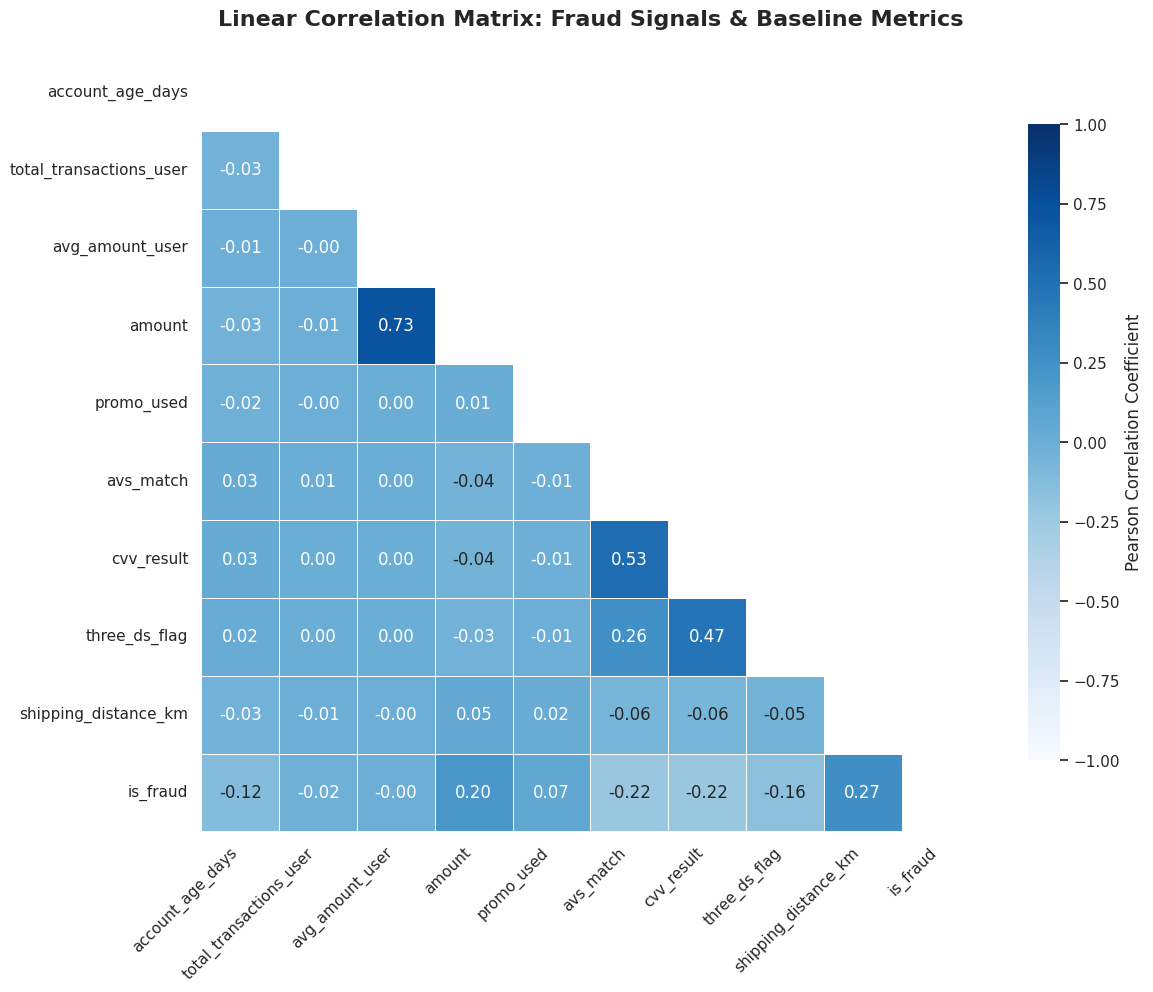

In [ ]:
# Linear Dependencies & Multicolinearity Check (Correlation Matrix)

# --- 1. SELECT NUMERIC AND BINARY COLUMNS ---
# ID variables and timestamps must be excluded as linear correlation holds no meaning for them
correlation_features = [
    'account_age_days', 'total_transactions_user', 'avg_amount_user',
    'amount', 'promo_used', 'avs_match', 'cvv_result',
    'three_ds_flag', 'shipping_distance_km', 'is_fraud'
]

# Extract the sub-dataframe
corr_df = df[correlation_features]

# --- 2. COMPUTE PEARSON CORRELATION MATRIX ---
corr_matrix = corr_df.corr(method='pearson')

# --- 3. CREATE A TRIANGULAR MASK (OPTIONAL BUT RECOMMENDED) ---
# A correlation matrix is perfectly symmetrical. Masking the upper triangle prevents redundant visual clutter.
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# --- 4. GRAPH CONFIGURATION & HEATMAP PLOTTING ---
plt.figure(figsize=(12, 10))
sns.set_theme(style="white")

# Setting up the blueprint using the requested blue color palette
sns.heatmap(
    corr_matrix,
    mask=mask,                  # Applies the triangular mask
    annot=True,                 # Forces numerical values inside cells
    fmt=".2f",                  # Standardizes decimals to 2 positions
    cmap="Blues",               # Sets the requested blue palette color spectrum
    vmin=-1, vmax=1,            # Ensures the color bar anchors strictly to standard limits
    square=True,                # Forces perfect square dimensions for every cell
    linewidths=0.5,             # Adds clean borders between matrix grids
    cbar_kws={"shrink": 0.8, "label": "Pearson Correlation Coefficient"} # Formats the side scale
)

# --- 5. VISUAL POLISHING ---
plt.title('Linear Correlation Matrix: Fraud Signals & Baseline Metrics',
          fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(fontsize=11)

plt.tight_layout()
plt.show()

The annotated triangular correlation matrix effectively quantifies the linear strength between independent features and isolates potential collinearity risks that could impact downstream model stability.

**1. Core Feature-to-Target Direct Signals (`is_fraud`)**

* **Logistical and Capital Triggers:** `shipping_distance_km` displays the strongest positive linear correlation with the target variable at **0.27**, closely followed by raw transaction `amount` at **0.20**. This statistically anchors our prior graphical findings: higher distances and elevated purchasing values are linear drivers of transaction risk.
* **Technical Security Defenses:** Both `avs_match` (**-0.22**) and `cvv_result` (**-0.22**) exhibit identical, significant negative correlations with fraud. The inverse relationship confirms that a successful security handshake (AVS match or correct CVV) acts as a powerful statistical dampener for transaction risk.
* **Account Maturity:** `account_age_days` establishes an inverse correlation of **-0.12**, confirming that younger or newly established user profiles carry an inherently higher linear baseline probability of being fraudulent.

**2. Multicollinearity & Feature Redundancy Diagnostics**

* **The Financial Redundancy Vector (`amount` $\times$ `avg_amount_user`):** A prominent correlation spike of **0.73** is detected between the current transaction amount and the user's historical baseline average. While mathematically logical (consumers tend to maintain stable spending habits), this severe collinearity can destabilize traditional linear models like Logistic Regression by inflating coefficient variance.
* **Security Layer Interdependence (`cvv_result` $\times$ `avs_match`):** A moderate-high positive correlation of **0.53** exists between these two verification systems. This indicates that security verification failures do not happen in isolation; a compromise or lack of credentials often triggers systemic failures across multiple automated authentication layers simultaneously.

**3. Data Engineering Roadmap Takeaways**
* **Algorithm Selection:** Due to the structural collinearity between absolute amounts and historical averages ($0.73$), tree-based ensembles (e.g., LightGBM, XGBoost) are strongly favored over linear classifiers, as they inherently handle correlated splits without degradation.
* **Feature Retention:** All security flags (`cvv_result`, `avs_match`, `three_ds_flag`) maintain independent linear relevance to the target and should be preserved as critical structural inputs for the upcoming training pipeline.

## **15. CONCLUSIONS**

Fraud in this dataset is driven not by the timing of transactions, but by geographic inconsistencies, financial behavior anomalies, security-related signals, and user profile characteristics.

- The dataset exhibits a significant class imbalance, with approximately 98% legitimate transactions and only 2% fraudulent transactions.

- Fraud rates remain remarkably stable across the 24-hour cycle, with no clearly identifiable high-risk time windows. Similarly, no meaningful variation is observed across weekdays. A modest increase is detected only during the final days of the month (days 29–31). These findings suggest that temporal variables possess limited predictive value for fraud detection. A substantial concentration of fraudulent transactions was observed among accounts that had been active for less than 50 days.

- Transactions exhibiting geographic discrepancies are approximately eight times more likely to be fraudulent than those without such discrepancies.

- Fraudulent actors tend to have products shipped to locations significantly farther from the account holder's usual residential address.

- Relative financial behavior carries greater predictive value than the absolute transaction amount. The analysis reveals two distinct fraud patterns: aggressive fraud, characterized by transaction amounts that substantially exceed a user's historical spending levels, and stealth fraud, characterized by transaction amounts that closely resemble normal spending behavior and are likely intended to circumvent simple rule-based detection mechanisms.

- The data provide no evidence that attackers typically engage in large bursts of transactions. The conventional assumption that fraud is characterized by "multiple transactions occurring within a short time frame" is not supported by the observed patterns. Fraudsters also do not typically engage in excessively large purchases.

- Fraud is a multidimensional phenomenon that emerges when multiple weak signals co-occur, such as recently created accounts, long shipping distances, anomalous spending relative to historical patterns, and geographic inconsistencies.

- Improved performance is expected from tree-based and boosting models compared to simple linear models